# Mixture-of-Experts (MoE) — with Log-Income Feature

## Motivation

Identical to `moe_model.ipynb` with one targeted change:
**`monthly_income` is log1p-transformed** before scaling and model training.

The raw income distribution is heavily right-skewed (skewness ≈ 5–8). While BatchNorm
mitigates internal covariate shift, a log transform reduces the leverage of extreme
income values on gradients during the early epochs and yields a near-Gaussian input —
potentially improving convergence and generalisation.

Everything else is held constant so any metric difference is attributable solely
to the income transformation.

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve,
    precision_recall_curve, confusion_matrix, f1_score, classification_report,
    precision_score, recall_score,
)
from scipy.stats import spearmanr

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

import umap

plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch: 2.8.0
CUDA available: False


## 1 · Data Loading & Preprocessing

Identical pipeline to the EDA notebook:
* Remove `age == 0` (single impossible-age record)
* Flag sentinel delinquency codes (`delinq_90 ∈ {96, 98}`) with `delinq_sentinel = 1`; cap all delinquency counts at 10
* Create missing-value indicator flags **before** imputation, derived from `raw` to be re-execution-safe
* Impute `monthly_income` with median, `dependents` with 0
* Log-transform `monthly_income` after imputation (key difference vs `moe_model.ipynb`)

In [2]:
raw = pd.read_csv('../Data/cs-training.csv', index_col=0)

RENAME = {
    'SeriousDlqin2yrs':                        'defaulted',
    'RevolvingUtilizationOfUnsecuredLines':     'unsecured_credit',
    'age':                                      'age',
    'NumberOfTime30-59DaysPastDueNotWorse':     'delinq_30_59',
    'DebtRatio':                                'debt_ratio',
    'MonthlyIncome':                            'monthly_income',
    'NumberOfOpenCreditLinesAndLoans':          'open_credit',
    'NumberOfTimes90DaysLate':                  'delinq_90',
    'NumberRealEstateLoansOrLines':             'real_estate_loans',
    'NumberOfTime60-89DaysPastDueNotWorse':     'delinq_60_89',
    'NumberOfDependents':                       'dependents',
}
raw = raw.rename(columns=RENAME)

df = raw.copy()
df = df[df['age'] > 0]

# Sentinel treatment: flag codes 96/98, cap all delinquency at 10
DELINQ_COLS = ['delinq_30_59', 'delinq_60_89', 'delinq_90']
df['delinq_sentinel'] = (df['delinq_90'] >= 96).astype(int)
for col in DELINQ_COLS:
    df[col] = df[col].clip(upper=10)

# Missing indicators -- must be derived from raw, not df
df['monthly_income_missing'] = raw.loc[df.index, 'monthly_income'].isna().astype(int)
df['dependents_missing']     = raw.loc[df.index, 'dependents'].isna().astype(int)

# Imputation
df['monthly_income'] = df['monthly_income'].fillna(df['monthly_income'].median())
df['dependents']     = df['dependents'].fillna(0)

print(f"Dataset shape   : {df.shape}")
print(f"Default rate    : {df['defaulted'].mean():.3%}")
print(f"Sentinel rows   : {df['delinq_sentinel'].sum():,}")

# ── Log-transform monthly_income (key change vs moe_model.ipynb) ─────────────
# Applied after imputation so the filled median is also transformed consistently.
df['monthly_income'] = np.log1p(df['monthly_income'])
print(f"monthly_income skewness after log1p : {df['monthly_income'].skew():.3f}  (was ~5-8 raw)")

Dataset shape   : (149999, 14)
Default rate    : 6.684%
Sentinel rows   : 269
monthly_income skewness after log1p : -4.938  (was ~5-8 raw)


## 2 · Class-Imbalance Analysis

With ~6.7 % defaults the dataset is heavily imbalanced.
We address this with a **class-weighted BCE loss**: `pos_weight = n_neg / n_pos ≈ 14`.
This makes each positive example count as much as ~14 negatives during training.

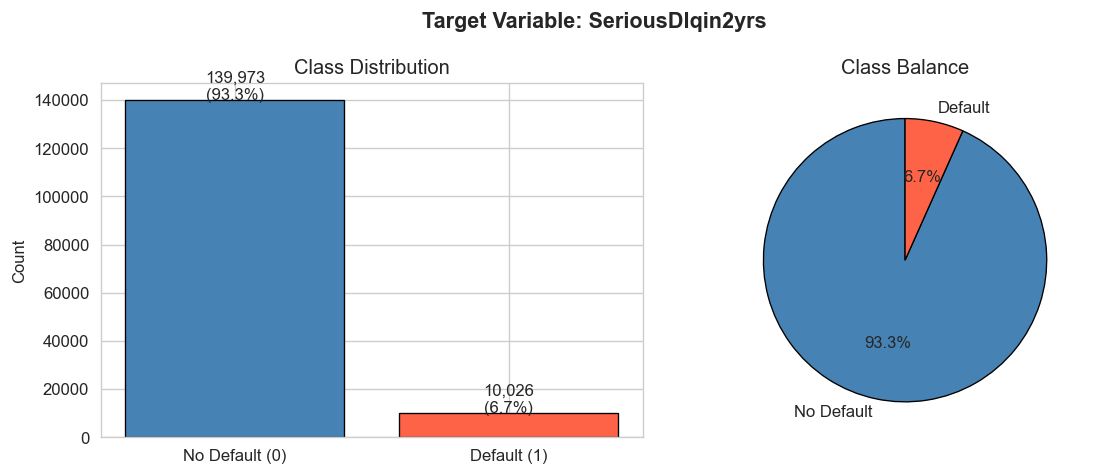

pos_weight for BCE: 13.96  (each default counted as 14.0x a non-default)


In [3]:
n_pos = int((df['defaulted'] == 1).sum())
n_neg = int((df['defaulted'] == 0).sum())
pos_weight_scalar = n_neg / n_pos

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

counts = [n_neg, n_pos]
labels = ['No Default (0)', 'Default (1)']
colors = ['steelblue', 'tomato']
axes[0].bar(labels, counts, color=colors, edgecolor='black', linewidth=0.8)
for i, v in enumerate(counts):
    axes[0].text(i, v + 300, f'{v:,}\n({v/len(df):.1%})', ha='center', fontsize=10)
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')

axes[1].pie(counts, labels=['No Default', 'Default'], colors=colors,
            autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'black', 'linewidth': 0.8})
axes[1].set_title('Class Balance')

plt.suptitle('Target Variable: SeriousDlqin2yrs', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(f"pos_weight for BCE: {pos_weight_scalar:.2f}  (each default counted as {pos_weight_scalar:.1f}x a non-default)")

## 3 · MoE Theory

### Soft Mixture-of-Experts

Given input $\mathbf{x} \in \mathbb{R}^d$, the model computes:

$$\hat{y} = \sum_{k=1}^{K} g_k(\mathbf{x}) \cdot f_k(\mathbf{x})$$

where
* $g_k(\mathbf{x}) = \text{softmax}(W_g \mathbf{x} + b_g)_k$ — gate weight for expert $k$
* $f_k(\mathbf{x})$ — logit produced by expert $k$ (a 3-layer MLP with BatchNorm + Dropout)
* The final sigmoid of $\hat{y}$ gives the default probability.

### Load-Balancing: Switch Transformer Auxiliary Loss (Fedus et al., 2022)

Without regularisation, the gating network collapses: one expert gets all the traffic
("expert collapse"), and the others never learn. We prevent this with:

$$\mathcal{L}_\text{aux} = \alpha \cdot K \cdot \sum_{k=1}^{K} f_k \cdot P_k$$

where
* $f_k = \frac{1}{N}\sum_i \mathbf{1}[\arg\max_j g_j(\mathbf{x}_i) = k]$ — fraction routed to expert $k$ (**non-differentiable**, treats routing as hard)
* $P_k = \frac{1}{N}\sum_i g_k(\mathbf{x}_i)$ — mean gate weight for expert $k$ (**differentiable**)
* At perfect balance: $f_k = P_k = 1/K$ for all $k$, so $\mathcal{L}_\text{aux} = \alpha \cdot K \cdot K \cdot (1/K^2) = \alpha$.

The total loss is:

$$\mathcal{L} = \mathcal{L}_\text{BCE}(\text{pos\_weight}) + \mathcal{L}_\text{aux}$$

## 4 · Model Implementation

In [4]:
class Expert(nn.Module):
    # 3-layer MLP: (Linear -> BN -> ReLU -> Dropout) x2 -> Linear output
    def __init__(self, input_dim, hidden_dim=64, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        return self.net(x)  # shape: (B, 1)


class GatingNetwork(nn.Module):
    # Lightweight 2-layer MLP: input -> 32 -> K softmax weights
    def __init__(self, input_dim, n_experts=3):
        super().__init__()
        self.gate = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, n_experts),
        )

    def forward(self, x):
        return F.softmax(self.gate(x), dim=-1)  # shape: (B, K)


class MixtureOfExperts(nn.Module):
    def __init__(self, input_dim, n_experts=3, hidden_dim=64, dropout=0.3):
        super().__init__()
        self.n_experts = n_experts
        self.experts = nn.ModuleList([
            Expert(input_dim, hidden_dim, dropout) for _ in range(n_experts)
        ])
        self.gate = GatingNetwork(input_dim, n_experts)

    def forward(self, x):
        gate_weights = self.gate(x)                          # (B, K)
        expert_outs = torch.cat([e(x) for e in self.experts], dim=1)  # (B, K)
        logits = (gate_weights * expert_outs).sum(dim=1)     # (B,)
        return logits, gate_weights


def auxiliary_loss(gate_weights, alpha=0.01):
    # Switch Transformer load-balancing loss (Fedus et al., 2022)
    K = gate_weights.shape[1]
    top_k = gate_weights.argmax(dim=1)           # hard routing (non-differentiable)
    f_k = torch.zeros(K, device=gate_weights.device)
    for k in range(K):
        f_k[k] = (top_k == k).float().mean()
    P_k = gate_weights.mean(dim=0)               # mean gate weight, differentiable
    return alpha * K * (f_k * P_k).sum()


print("Model classes defined: Expert, GatingNetwork, MixtureOfExperts")
print("Auxiliary loss: Switch Transformer load-balancing (Fedus et al., 2022)")

Model classes defined: Expert, GatingNetwork, MixtureOfExperts
Auxiliary loss: Switch Transformer load-balancing (Fedus et al., 2022)


## 5 · Training Setup

| Hyperparameter | Value | Rationale |
|---|---|---|
| Experts $K$ | 3 | Enough to capture subpopulation structure without over-parameterising |
| Hidden dim | 64 | Small enough to prevent overfitting on tabular data |
| Dropout | 0.3 | Regularisation within each expert |
| Batch size | 512 | Stable BatchNorm statistics |
| Optimiser | Adam | lr=1e-3, weight_decay=1e-4 |
| Scheduler | ReduceLROnPlateau | factor=0.5, patience=3, monitor val AUC |
| Early stopping | patience=8 | Restore best val-AUC checkpoint |
| Aux $\alpha$ | 0.01 | Gentle load-balancing pressure |
| **`POS_WEIGHT`** | **7.0** (default ~14) | **Option 2**: reduce from data ratio to trade recall for precision — lower = fewer false positives |
| **`PREC_TARGET`** | **0.50** | **Option 1**: minimum acceptable Default-class precision for threshold selection |
| Split | 70 / 15 / 15 | Stratified to preserve class ratio |

In [5]:
SEED       = 42
HIDDEN_DIM = 64
DROPOUT    = 0.3
N_EXPERTS  = 3
BATCH_SIZE = 512
LR         = 1e-3
WEIGHT_DECAY = 1e-4
MAX_EPOCHS = 400
PATIENCE   = 100
AUX_ALPHA  = 0.01
TEMPERATURE = 3.0   # for knowledge distillation

# Option 2: explicit pos_weight (reduce from data ratio ~14 to improve default-class precision).
# Lowering this makes the model more conservative about predicting positives:
# fewer false positives -> higher precision, but lower recall.
# Set to None to use the data ratio (n_neg / n_pos) automatically.
POS_WEIGHT = 7.0    # try 5–14; None = use data ratio

torch.manual_seed(SEED)
np.random.seed(SEED)

FEATURE_COLS = [
    'unsecured_credit', 'age', 'delinq_30_59', 'debt_ratio',
    'monthly_income', 'open_credit', 'delinq_90', 'real_estate_loans',
    'delinq_60_89', 'dependents', 'monthly_income_missing', 'dependents_missing',
    'delinq_sentinel',
]

X = df[FEATURE_COLS].values.astype(np.float32)
y = df['defaulted'].values.astype(np.float32)

# 70 / 15 / 15 stratified split
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15/0.85, random_state=SEED, stratify=y_temp)

# Scale
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print(f"Train : {X_train_s.shape}  default={y_train.mean():.3%}")
print(f"Val   : {X_val_s.shape}   default={y_val.mean():.3%}")
print(f"Test  : {X_test_s.shape}  default={y_test.mean():.3%}")

def make_loader(X, y, batch_size, shuffle=True):
    ds = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.float32),
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(X_train_s, y_train, BATCH_SIZE, shuffle=True)
val_loader   = make_loader(X_val_s,   y_val,   BATCH_SIZE, shuffle=False)
test_loader  = make_loader(X_test_s,  y_test,  BATCH_SIZE, shuffle=False)

n_pos_train = int(y_train.sum())
n_neg_train = int(len(y_train) - n_pos_train)
data_ratio  = n_neg_train / n_pos_train
pw          = POS_WEIGHT if POS_WEIGHT is not None else data_ratio
pos_weight_tensor = torch.tensor([pw], dtype=torch.float32)

print(f"\nData ratio  (n_neg/n_pos) : {data_ratio:.2f}")
print(f"pos_weight  (used)        : {pw:.2f}  {'← configured (Option 2)' if POS_WEIGHT is not None else '← data ratio'}")

Train : (104999, 13)  default=6.684%
Val   : (22500, 13)   default=6.684%
Test  : (22500, 13)  default=6.684%

Data ratio  (n_neg/n_pos) : 13.96
pos_weight  (used)        : 7.00  ← configured (Option 2)


## 6 · Training Loop

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on: {device}")

model = MixtureOfExperts(
    input_dim=len(FEATURE_COLS),
    n_experts=N_EXPERTS,
    hidden_dim=HIDDEN_DIM,
    dropout=DROPOUT,
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

bce_fn    = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor.to(device))
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3)

history = {'train_loss': [], 'val_loss': [], 'val_auc': [], 'aux_loss': []}
best_val_auc    = 0.0
best_state      = None
patience_counter = 0

for epoch in range(1, MAX_EPOCHS + 1):
    # ---- train ----
    model.train()
    t_loss, t_aux = [], []
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits, gw = model(Xb)
        loss  = bce_fn(logits, yb)
        aux   = auxiliary_loss(gw, alpha=AUX_ALPHA)
        (loss + aux).backward()
        optimizer.step()
        t_loss.append(loss.item())
        t_aux.append(aux.item())

    # ---- validate ----
    model.eval()
    v_loss, v_prob = [], []
    with torch.no_grad():
        for Xb, yb in val_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            logits, gw = model(Xb)
            v_loss.append(bce_fn(logits, yb).item())
            v_prob.append(torch.sigmoid(logits).cpu().numpy())

    v_probs  = np.concatenate(v_prob)
    val_auc  = roc_auc_score(y_val, v_probs)

    history['train_loss'].append(np.mean(t_loss))
    history['val_loss'].append(np.mean(v_loss))
    history['val_auc'].append(val_auc)
    history['aux_loss'].append(np.mean(t_aux))

    scheduler.step(val_auc)

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
        marker = ' ✓'
    else:
        patience_counter += 1
        marker = ''

    if epoch % 5 == 0 or patience_counter == 0:
        print(f"Epoch {epoch:3d} | bce={np.mean(t_loss):.4f}  aux={np.mean(t_aux):.4f} "
              f"| val_bce={np.mean(v_loss):.4f}  val_auc={val_auc:.4f}  "
              f"patience={patience_counter}{marker}")

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}")
        break

model.load_state_dict(best_state)
print(f"\nBest val AUC: {best_val_auc:.4f}")

Training on: cpu
Total parameters: 16,678


Epoch   1 | bce=0.6977  aux=0.0108 | val_bce=0.6680  val_auc=0.8199  patience=0 ✓


Epoch   2 | bce=0.6522  aux=0.0101 | val_bce=0.6620  val_auc=0.8231  patience=0 ✓


Epoch   3 | bce=0.6503  aux=0.0100 | val_bce=0.6588  val_auc=0.8266  patience=0 ✓


Epoch   4 | bce=0.6479  aux=0.0100 | val_bce=0.6580  val_auc=0.8270  patience=0 ✓


...

Epoch 125 | bce=0.6362  aux=0.0100 | val_bce=0.6527  val_auc=0.8298  patience=80


Epoch 130 | bce=0.6336  aux=0.0100 | val_bce=0.6532  val_auc=0.8297  patience=85


Epoch 135 | bce=0.6345  aux=0.0100 | val_bce=0.6528  val_auc=0.8295  patience=90


Epoch 140 | bce=0.6343  aux=0.0100 | val_bce=0.6533  val_auc=0.8299  patience=95


Epoch 145 | bce=0.6436  aux=0.0100 | val_bce=0.6526  val_auc=0.8298  patience=100

Early stopping at epoch 145

Best val AUC: 0.8299


## 7 · Training Diagnostics

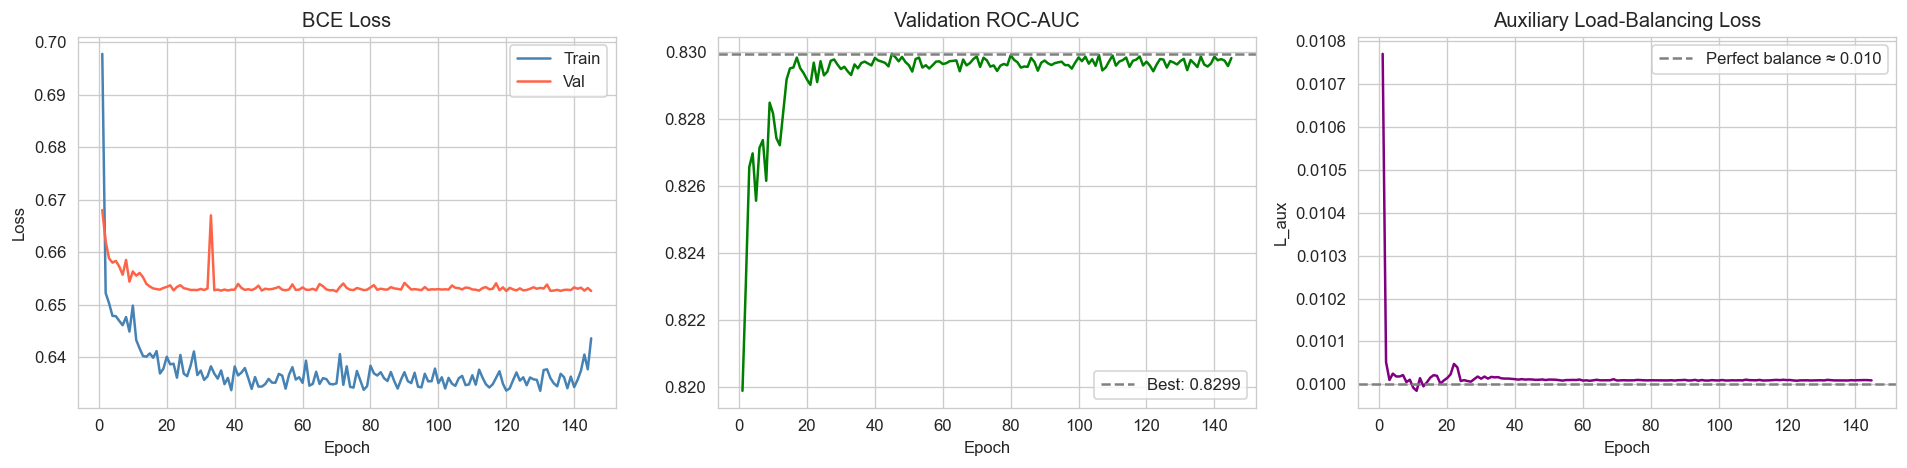

In [7]:
epochs_x = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Loss curves
axes[0].plot(epochs_x, history['train_loss'], label='Train', color='steelblue', lw=1.5)
axes[0].plot(epochs_x, history['val_loss'],   label='Val',   color='tomato',    lw=1.5)
axes[0].set_title('BCE Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Val AUC
axes[1].plot(epochs_x, history['val_auc'], color='green', lw=1.5)
axes[1].axhline(best_val_auc, color='gray', linestyle='--',
                label=f'Best: {best_val_auc:.4f}')
axes[1].set_title('Validation ROC-AUC')
axes[1].set_xlabel('Epoch')
axes[1].legend()

# Auxiliary load-balancing loss
axes[2].plot(epochs_x, history['aux_loss'], color='purple', lw=1.5)
# Perfect-balance reference line: alpha * K * K * (1/K^2) = alpha
axes[2].axhline(AUX_ALPHA, color='gray', linestyle='--',
                label=f'Perfect balance ≈ {AUX_ALPHA:.3f}')
axes[2].set_title('Auxiliary Load-Balancing Loss')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('L_aux')
axes[2].legend()

plt.tight_layout()
plt.show()

## 8 · Test-Set Evaluation

We evaluate on the held-out 15 % test set using **two threshold strategies**, both tuned on the validation set:

| Strategy | Criterion | Effect |
|---|---|---|
| **Max-F1** | $\arg\max_t F_1(t)$ | Balanced precision / recall |
| **Precision-targeted** | $\arg\max_t \text{Recall}(t)$ s.t. $\text{Precision}(t) \geq \tau$ | Explicit precision floor (tunable via `PREC_TARGET`) |

Both thresholds are shown on the PR curve and in side-by-side confusion matrices.
`best_thresh` at the end of the cell selects which one propagates to downstream cells (UMAP, distillation).

Reported metrics:
* **ROC-AUC** — threshold-independent ranking quality
* **Average Precision** — area under the PR curve, better for imbalanced classes
* **Confusion matrix** — side-by-side for both thresholds
* **Classification report** — precision, recall, F1 per class at each threshold

Strategy A — Max-F1          : t=0.606  prec=0.359  rec=0.485  F1=0.413
Strategy B — Prec≥50%      : t=0.823  prec=0.501  rec=0.204


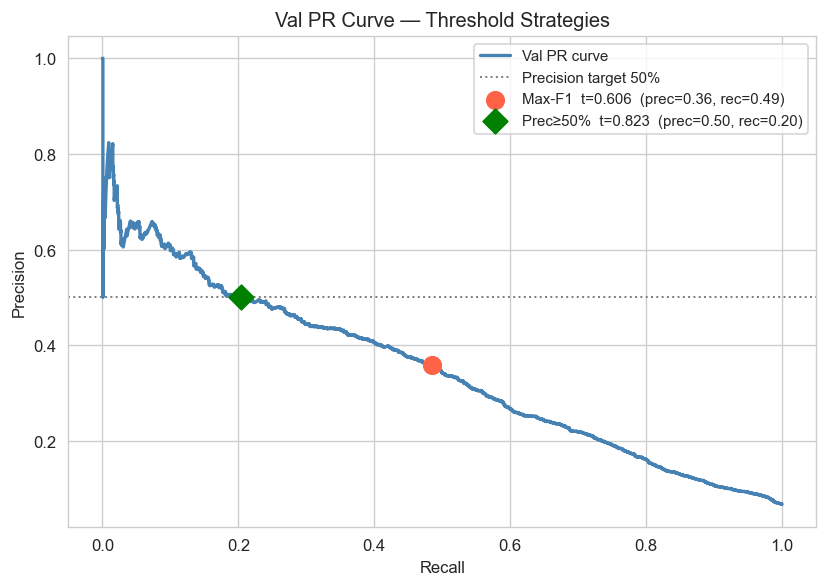


Active threshold : 0.823  (precision-targeted)
  → change `best_thresh = thresh_f1` to activate max-F1 strategy instead

MoE Teacher — Test ROC-AUC      : 0.8430
MoE Teacher — Avg Precision     : 0.3613

── Strategy A: Max-F1 (t=0.606) ──
              precision    recall  f1-score   support

  No Default       0.96      0.94      0.95     20996
     Default       0.37      0.50      0.42      1504

    accuracy                           0.91     22500
   macro avg       0.67      0.72      0.69     22500
weighted avg       0.92      0.91      0.92     22500

── Strategy B: Prec≥50% (t=0.823) ──
              precision    recall  f1-score   support

  No Default       0.95      0.98      0.97     20996
     Default       0.52      0.23      0.32      1504

    accuracy                           0.93     22500
   macro avg       0.73      0.61      0.64     22500
weighted avg       0.92      0.93      0.92     22500



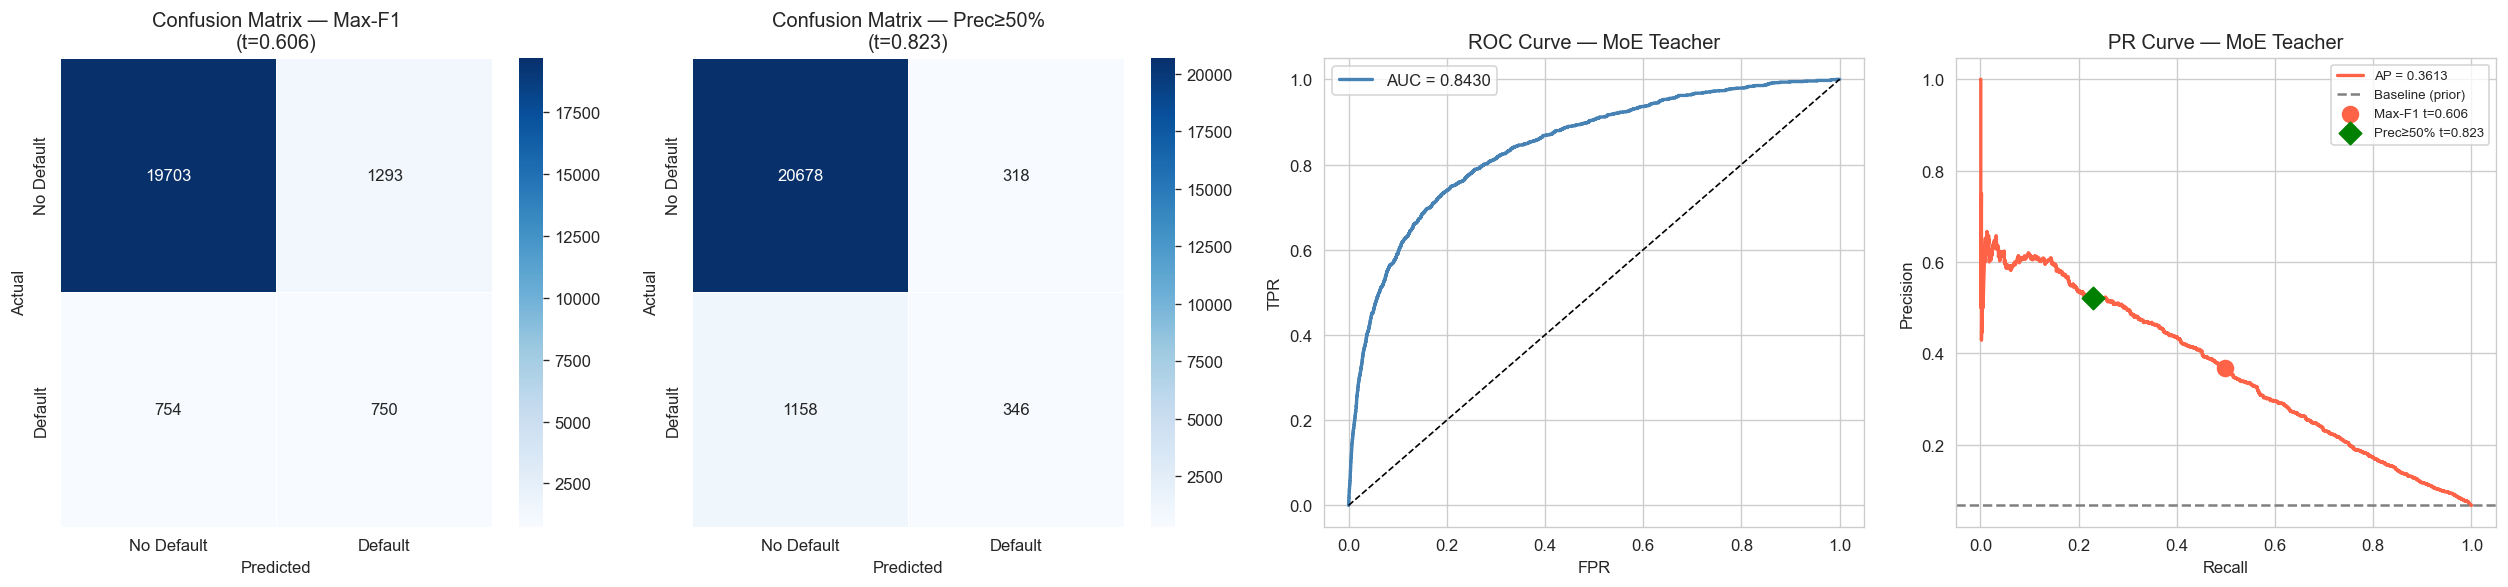

In [8]:
# Option 1: precision-targeted threshold
# Minimum acceptable precision on the Default class — tune this.
PREC_TARGET = 0.50

# ── collect validation probabilities ─────────────────────────────────────────
model.eval()
val_p_all = []
with torch.no_grad():
    for Xb, _ in val_loader:
        logits, _ = model(Xb.to(device))
        val_p_all.append(torch.sigmoid(logits).cpu().numpy())
val_p_all = np.concatenate(val_p_all)

# ── sweep thresholds on val ───────────────────────────────────────────────────
thresholds = np.linspace(0.01, 0.99, 499)
prec_vals  = np.array([precision_score(y_val, val_p_all >= t, zero_division=0) for t in thresholds])
rec_vals   = np.array([recall_score(y_val,    val_p_all >= t, zero_division=0) for t in thresholds])
f1_vals    = np.array([f1_score(y_val,        val_p_all >= t, zero_division=0) for t in thresholds])

# Strategy A: max F1
thresh_f1   = thresholds[int(np.argmax(f1_vals))]
prec_f1     = prec_vals[int(np.argmax(f1_vals))]
rec_f1      = rec_vals[int(np.argmax(f1_vals))]

# Strategy B: highest recall where precision >= PREC_TARGET
feasible = prec_vals >= PREC_TARGET
if feasible.any():
    best_idx    = feasible.nonzero()[0][int(np.argmax(rec_vals[feasible]))]
    thresh_prec = thresholds[best_idx]
    prec_prec   = prec_vals[best_idx]
    rec_prec    = rec_vals[best_idx]
else:
    thresh_prec = thresholds[int(np.argmax(prec_vals))]
    prec_prec   = prec_vals[int(np.argmax(prec_vals))]
    rec_prec    = rec_vals[int(np.argmax(prec_vals))]
    print(f"Warning: precision target {PREC_TARGET:.0%} never achieved; using max-precision threshold.")

print(f"Strategy A — Max-F1          : t={thresh_f1:.3f}  prec={prec_f1:.3f}  rec={rec_f1:.3f}  F1={f1_vals[int(np.argmax(f1_vals))]:.3f}")
print(f"Strategy B — Prec≥{PREC_TARGET:.0%}      : t={thresh_prec:.3f}  prec={prec_prec:.3f}  rec={rec_prec:.3f}")

# PR curve showing both operating points
prec_curve, rec_curve, _ = precision_recall_curve(y_val, val_p_all)
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(rec_curve, prec_curve, color='steelblue', lw=2, label='Val PR curve')
ax.axhline(PREC_TARGET, color='gray', linestyle=':', lw=1.2, label=f'Precision target {PREC_TARGET:.0%}')
ax.scatter([rec_f1],   [prec_f1],   color='tomato', s=110, zorder=5,
           label=f'Max-F1  t={thresh_f1:.3f}  (prec={prec_f1:.2f}, rec={rec_f1:.2f})')
ax.scatter([rec_prec], [prec_prec], color='green',  s=110, marker='D', zorder=5,
           label=f'Prec≥{PREC_TARGET:.0%}  t={thresh_prec:.3f}  (prec={prec_prec:.2f}, rec={rec_prec:.2f})')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Val PR Curve — Threshold Strategies')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

# Active threshold: swap to thresh_f1 to prefer max-F1 behaviour
best_thresh = thresh_prec
print(f"\nActive threshold : {best_thresh:.3f}  (precision-targeted)")
print("  → change `best_thresh = thresh_f1` to activate max-F1 strategy instead")

# ── test-set inference ────────────────────────────────────────────────────────
test_probs, test_gate_w = [], []
with torch.no_grad():
    for Xb, _ in test_loader:
        logits, gw = model(Xb.to(device))
        test_probs.append(torch.sigmoid(logits).cpu().numpy())
        test_gate_w.append(gw.cpu().numpy())

test_probs  = np.concatenate(test_probs)
test_gate_w = np.concatenate(test_gate_w)

test_preds_f1   = (test_probs >= thresh_f1).astype(int)
test_preds_prec = (test_probs >= thresh_prec).astype(int)
test_preds      = (test_probs >= best_thresh).astype(int)   # active

test_auc = roc_auc_score(y_test, test_probs)
test_ap  = average_precision_score(y_test, test_probs)
print(f"\nMoE Teacher — Test ROC-AUC      : {test_auc:.4f}")
print(f"MoE Teacher — Avg Precision     : {test_ap:.4f}")

print(f"\n── Strategy A: Max-F1 (t={thresh_f1:.3f}) ──")
print(classification_report(y_test, test_preds_f1, target_names=['No Default', 'Default']))

print(f"── Strategy B: Prec≥{PREC_TARGET:.0%} (t={thresh_prec:.3f}) ──")
print(classification_report(y_test, test_preds_prec, target_names=['No Default', 'Default']))

# ── plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(21, 5))

# Confusion matrices — side by side
for ax, preds, t, label in [
    (axes[0], test_preds_f1,   thresh_f1,   f'Max-F1\n(t={thresh_f1:.3f})'),
    (axes[1], test_preds_prec, thresh_prec, f'Prec≥{PREC_TARGET:.0%}\n(t={thresh_prec:.3f})'),
]:
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues',
                xticklabels=['No Default', 'Default'],
                yticklabels=['No Default', 'Default'], linewidths=0.5)
    ax.set_title(f'Confusion Matrix — {label}')
    ax.set_ylabel('Actual'); ax.set_xlabel('Predicted')

# ROC
fpr, tpr, _ = roc_curve(y_test, test_probs)
axes[2].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {test_auc:.4f}')
axes[2].plot([0, 1], [0, 1], 'k--', lw=1)
axes[2].set_title('ROC Curve — MoE Teacher')
axes[2].set_xlabel('FPR'); axes[2].set_ylabel('TPR'); axes[2].legend()

# PR with operating points
pc, rc, _ = precision_recall_curve(y_test, test_probs)
axes[3].plot(rc, pc, color='tomato', lw=2, label=f'AP = {test_ap:.4f}')
axes[3].axhline(y_test.mean(), color='gray', linestyle='--', label='Baseline (prior)')
axes[3].scatter([recall_score(y_test, test_preds_f1)],
                [precision_score(y_test, test_preds_f1)],
                color='tomato', s=90, zorder=5, label=f'Max-F1 t={thresh_f1:.3f}')
axes[3].scatter([recall_score(y_test, test_preds_prec)],
                [precision_score(y_test, test_preds_prec)],
                color='green', s=90, marker='D', zorder=5,
                label=f'Prec≥{PREC_TARGET:.0%} t={thresh_prec:.3f}')
axes[3].set_title('PR Curve — MoE Teacher')
axes[3].set_xlabel('Recall'); axes[3].set_ylabel('Precision')
axes[3].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 9 · Expert Specialisation Analysis

We inspect **which expert is dominant** (argmax gate weight) for each test sample and ask:
* Are the experts equally loaded?
* Do different experts "see" different default rates, suggesting they specialise on different borrower segments?
* What is the distribution of gate confidence (max gate weight)?

Expert load distribution on test set:
Expert       Dominant %   Mean gate wt   Default rate
----------------------------------------------------
Expert 0        32.01%         0.3127         2.110%
Expert 1        35.49%         0.3415         8.415%
Expert 2        32.49%         0.3458         9.301%


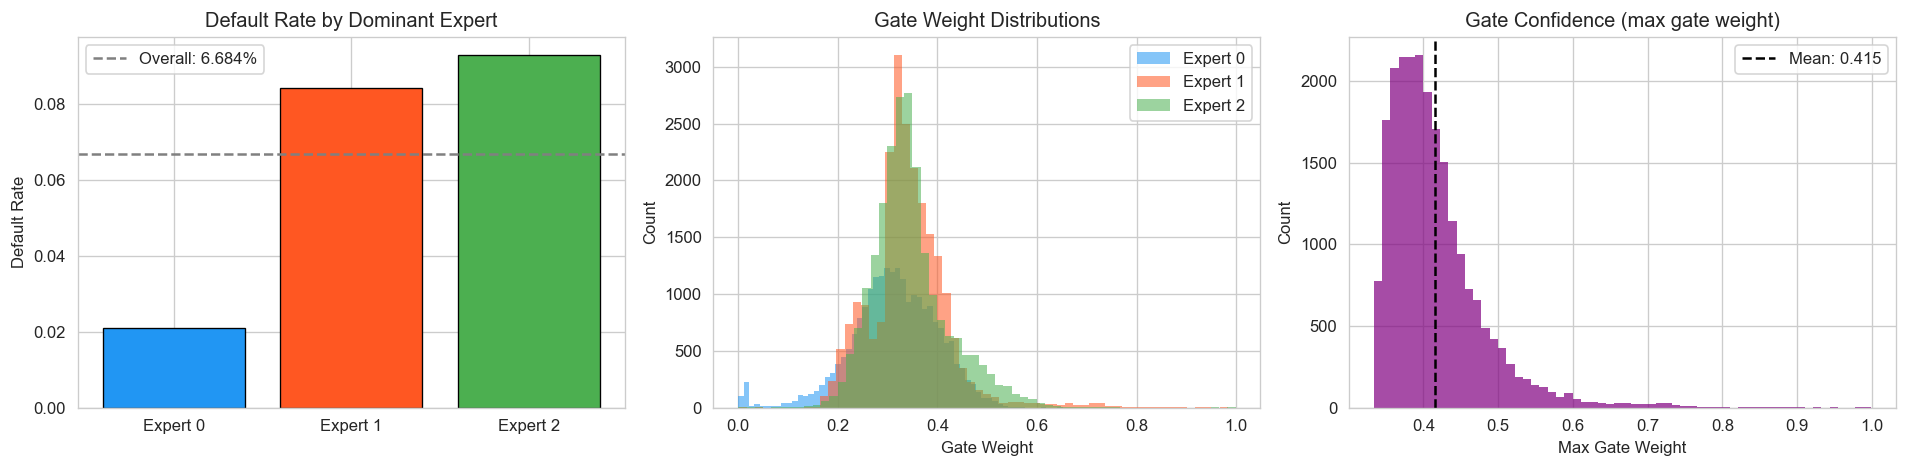

In [9]:
dominant_expert  = test_gate_w.argmax(axis=1)      # (N_test,)
gate_confidence  = test_gate_w.max(axis=1)          # (N_test,)

print("Expert load distribution on test set:")
print(f"{'Expert':<10} {'Dominant %':>12} {'Mean gate wt':>14} {'Default rate':>14}")
print('-' * 52)
expert_dr = []
for k in range(N_EXPERTS):
    mask = dominant_expert == k
    frac = mask.mean()
    mgw  = test_gate_w[:, k].mean()
    dr   = y_test[mask].mean() if mask.sum() > 0 else 0.0
    expert_dr.append(dr)
    print(f"Expert {k}  {frac:>12.2%} {mgw:>14.4f} {dr:>14.3%}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Default rate per expert
expert_labels = [f'Expert {k}' for k in range(N_EXPERTS)]
bar_colors    = ['#2196F3', '#FF5722', '#4CAF50']
axes[0].bar(expert_labels, expert_dr, color=bar_colors, edgecolor='black', linewidth=0.8)
axes[0].axhline(y_test.mean(), color='gray', linestyle='--', label=f'Overall: {y_test.mean():.3%}')
axes[0].set_title('Default Rate by Dominant Expert')
axes[0].set_ylabel('Default Rate')
axes[0].legend()

# Gate weight distributions (all 3 experts)
for k in range(N_EXPERTS):
    axes[1].hist(test_gate_w[:, k], bins=60, alpha=0.55,
                 label=f'Expert {k}', color=bar_colors[k], edgecolor='none')
axes[1].set_title('Gate Weight Distributions')
axes[1].set_xlabel('Gate Weight')
axes[1].set_ylabel('Count')
axes[1].legend()

# Gate confidence histogram
axes[2].hist(gate_confidence, bins=60, color='purple', alpha=0.7, edgecolor='none')
axes[2].axvline(gate_confidence.mean(), color='black', linestyle='--',
                label=f'Mean: {gate_confidence.mean():.3f}')
axes[2].set_title('Gate Confidence (max gate weight)')
axes[2].set_xlabel('Max Gate Weight')
axes[2].set_ylabel('Count')
axes[2].legend()

plt.tight_layout()
plt.show()

## 9b · Per-Expert Deep Analysis

Beyond load and default rate, we want to know **what each expert has learned**:

| Analysis | Method |
|---|---|
| Feature importance per expert | Mean absolute input gradient of expert_k(x) w.r.t. x |
| Feature profiles per expert | Mean standardised feature values for each expert's dominant samples |
| Metrics per expert | AUC, Precision, Recall, F1 on each expert's dominant test samples |

**Gradient-based importance** treats each expert as an isolated MLP and asks: *which input
dimensions move its output most?* Because we average \|∂f_k/∂x\| over many samples, this
is a global sensitivity measure — analogous to a per-expert permutation importance but
computed analytically.

Normalised mean |gradient| per feature per expert:
                        Expert 0  Expert 1  Expert 2
unsecured_credit          0.0167    0.0119    0.0271
age                       0.0445    0.0803    0.1185
delinq_30_59              0.1515    0.1428    0.1290
debt_ratio                0.0248    0.0243    0.0194
monthly_income            0.1471    0.0308    0.0204
open_credit               0.0619    0.1098    0.0648
delinq_90                 0.1470    0.2081    0.2082
real_estate_loans         0.0425    0.0507    0.0708
delinq_60_89              0.1009    0.1299    0.1353
dependents                0.0242    0.0251    0.0354
monthly_income_missing    0.0528    0.0291    0.0316
dependents_missing        0.0139    0.0153    0.0160
delinq_sentinel           0.1721    0.1419    0.1233


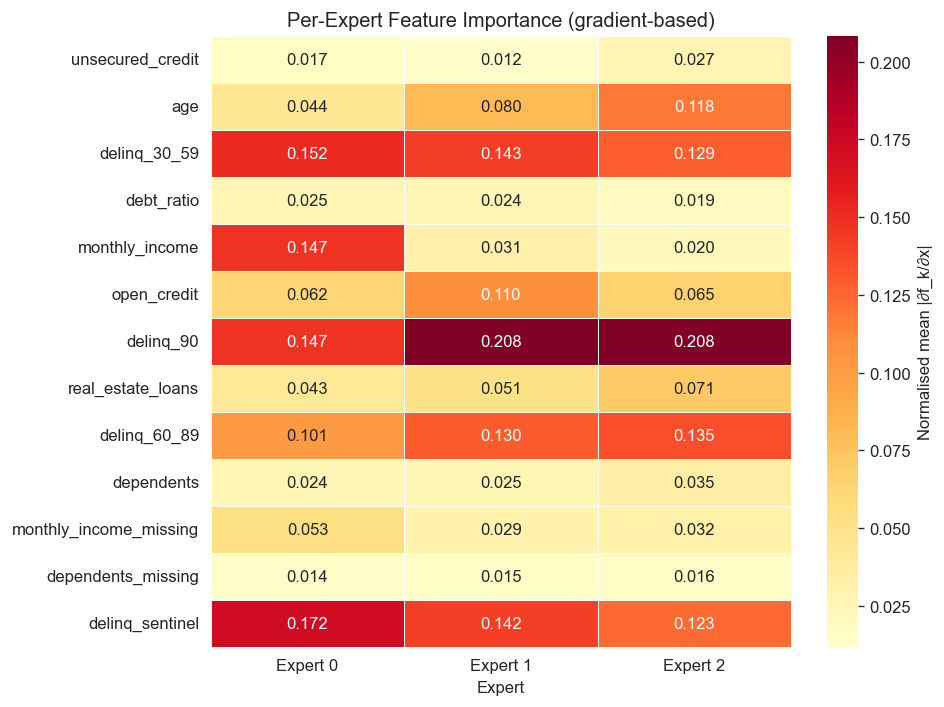

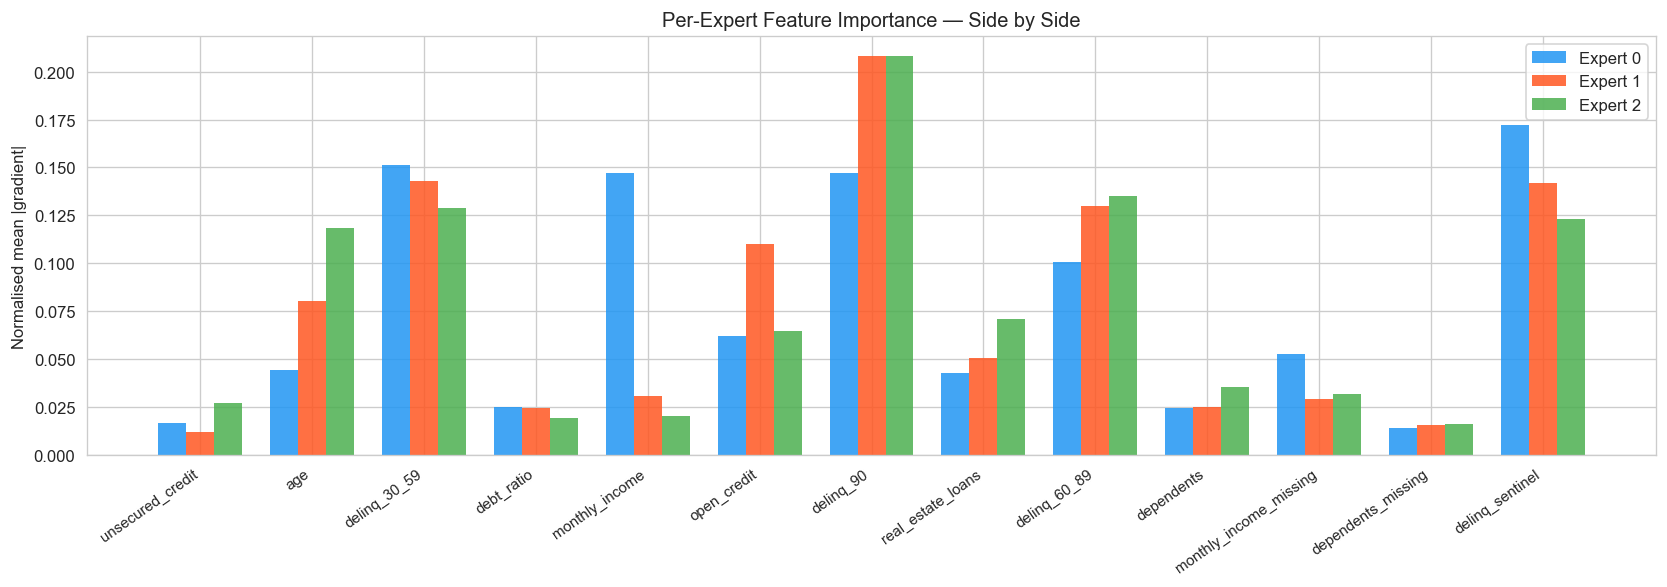

In [10]:
# ── Per-expert gradient-based feature importance ─────────────────────────────
model.eval()

all_grads = [[] for _ in range(N_EXPERTS)]

for i in range(0, len(X_test_s), 256):
    Xb = torch.tensor(X_test_s[i:i+256], dtype=torch.float32, requires_grad=True).to(device)
    for k in range(N_EXPERTS):
        out = model.experts[k](Xb).sum()
        grad = torch.autograd.grad(out, Xb, retain_graph=(k < N_EXPERTS - 1))[0]
        all_grads[k].append(grad.abs().detach().cpu().numpy())

# Mean |grad| per feature per expert  —  shape (N_EXPERTS, n_features)
expert_importance = np.array([
    np.vstack(all_grads[k]).mean(axis=0) for k in range(N_EXPERTS)
])

# Normalise each expert's row to sum to 1 for comparability
expert_imp_norm = expert_importance / expert_importance.sum(axis=1, keepdims=True)

imp_df = pd.DataFrame(expert_imp_norm.T, index=FEATURE_COLS,
                      columns=[f'Expert {k}' for k in range(N_EXPERTS)])
print("Normalised mean |gradient| per feature per expert:")
print(imp_df.round(4).to_string())

# ── Heatmap ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(imp_df, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Normalised mean |∂f_k/∂x|'})
ax.set_title('Per-Expert Feature Importance (gradient-based)', fontsize=12)
ax.set_xlabel('Expert')
plt.tight_layout()
plt.show()

# ── Grouped bar chart ──────────────────────────────────────────────────────────
bar_colors = ['#2196F3', '#FF5722', '#4CAF50']
x = np.arange(len(FEATURE_COLS))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 5))
for k in range(N_EXPERTS):
    ax.bar(x + k*width, expert_imp_norm[k], width, label=f'Expert {k}',
           color=bar_colors[k], alpha=0.85, edgecolor='none')
ax.set_xticks(x + width)
ax.set_xticklabels(FEATURE_COLS, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Normalised mean |gradient|')
ax.set_title('Per-Expert Feature Importance — Side by Side')
ax.legend()
plt.tight_layout()
plt.show()

Mean standardised feature values per expert (dominant samples):
          unsecured_credit    age  delinq_30_59  debt_ratio  monthly_income  open_credit  delinq_90  real_estate_loans  delinq_60_89  dependents  monthly_income_missing  dependents_missing  delinq_sentinel
Expert 0            -0.016  0.897        -0.183       0.045           0.311        0.245     -0.164              0.104        -0.116      -0.315                   0.204              -0.147           -0.042
Expert 1             0.050 -0.423         0.109      -0.093          -0.129        0.250      0.139              0.297         0.048       0.323                  -0.293               0.265            0.077
Expert 2            -0.022 -0.446         0.063       0.048          -0.145       -0.564      0.016             -0.440         0.047      -0.018                   0.133              -0.154           -0.042


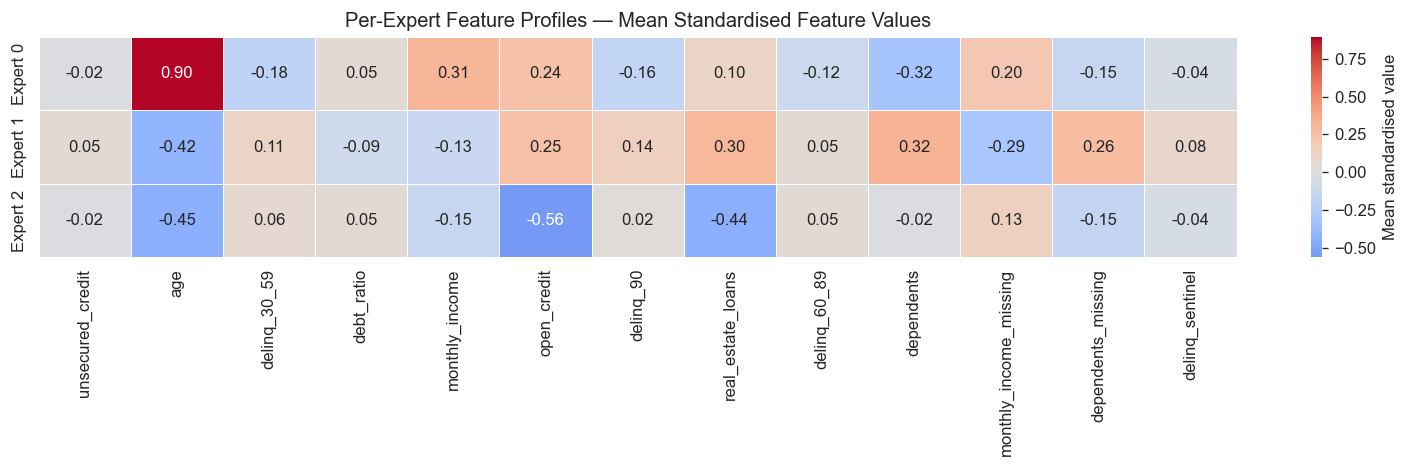

In [11]:
# ── Per-expert feature profiles ───────────────────────────────────────────────
# Mean standardised feature values for samples each expert dominates.
# Reveals the "borrower type" each expert specialises on.

dominant_expert = test_gate_w.argmax(axis=1)

profiles = np.array([
    X_test_s[dominant_expert == k].mean(axis=0) for k in range(N_EXPERTS)
])  # shape (N_EXPERTS, n_features)

profile_df = pd.DataFrame(profiles, index=[f'Expert {k}' for k in range(N_EXPERTS)],
                           columns=FEATURE_COLS)

print("Mean standardised feature values per expert (dominant samples):")
print(profile_df.round(3).to_string())

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(profile_df, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=ax, linewidths=0.5, cbar_kws={'label': 'Mean standardised value'})
ax.set_title('Per-Expert Feature Profiles — Mean Standardised Feature Values', fontsize=12)
plt.tight_layout()
plt.show()

Expert          N   Default%      AUC       F1     Prec      Rec
----------------------------------------------------------------
Expert 0    7203      2.11%   0.7840   0.0000   0.0000   0.0000
Expert 1    7986      8.41%   0.8264   0.3841   0.5796   0.2872
Expert 2    7311      9.30%   0.8222   0.3030   0.4636   0.2250


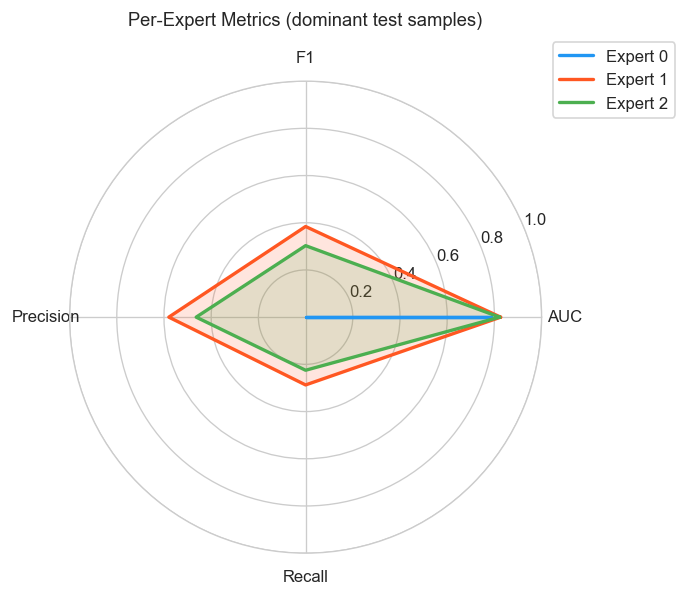

In [12]:
# ── Per-expert metrics on dominant test samples ───────────────────────────────
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score

print(f"{'Expert':<10} {'N':>6} {'Default%':>10} {'AUC':>8} {'F1':>8} {'Prec':>8} {'Rec':>8}")
print('-' * 64)

expert_metrics = {}
for k in range(N_EXPERTS):
    mask = dominant_expert == k
    n    = mask.sum()
    if n < 20:
        print(f"Expert {k}  {n:>6}  (too few samples)")
        continue
    yk     = y_test[mask]
    pk     = test_probs[mask]
    preds_k = (pk >= best_thresh).astype(int)
    auc_k  = roc_auc_score(yk, pk) if yk.sum() > 0 else float('nan')
    f1_k   = f1_score(yk, preds_k, zero_division=0)
    pr_k   = precision_score(yk, preds_k, zero_division=0)
    rc_k   = recall_score(yk, preds_k, zero_division=0)
    expert_metrics[k] = dict(n=n, dr=yk.mean(), auc=auc_k, f1=f1_k, prec=pr_k, rec=rc_k)
    print(f"Expert {k}  {n:>6} {yk.mean():>10.2%} {auc_k:>8.4f} {f1_k:>8.4f} {pr_k:>8.4f} {rc_k:>8.4f}")

# ── Radar / spider chart of per-expert metrics ────────────────────────────────
metric_keys  = ['auc', 'f1', 'prec', 'rec']
metric_labels = ['AUC', 'F1', 'Precision', 'Recall']
angles = np.linspace(0, 2*np.pi, len(metric_keys), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
bar_colors = ['#2196F3', '#FF5722', '#4CAF50']
for k, color in zip(range(N_EXPERTS), bar_colors):
    if k not in expert_metrics:
        continue
    vals = [expert_metrics[k][m] for m in metric_keys] + [expert_metrics[k][metric_keys[0]]]
    ax.plot(angles, vals, color=color, lw=2, label=f'Expert {k}')
    ax.fill(angles, vals, color=color, alpha=0.15)

ax.set_thetagrids(np.degrees(angles[:-1]), metric_labels)
ax.set_ylim(0, 1)
ax.set_title('Per-Expert Metrics (dominant test samples)', fontsize=11, pad=15)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

## 10 · UMAP Projection

**UMAP** (Uniform Manifold Approximation and Projection, McInnes et al., 2018) embeds
high-dimensional data into 2-D while preserving local neighbourhood structure better
than t-SNE and with faster inference.

We fit UMAP on a random subsample of 8,000 training points (for speed) and produce a
**4-panel** visualisation to understand how the MoE carves up the borrower space:

| Panel | Colour |
|---|---|
| 1 | Dominant expert (argmax gate weight) |
| 2 | Actual class (0 / 1) |
| 3 | Predicted class (0 / 1) |
| 4 | Gate confidence (max gate weight) |

In [13]:
np.random.seed(SEED)
umap_idx  = np.random.choice(len(X_train_s), size=min(8000, len(X_train_s)), replace=False)
X_umap    = X_train_s[umap_idx]
y_umap    = y_train[umap_idx]

model.eval()
with torch.no_grad():
    Xt = torch.tensor(X_umap, dtype=torch.float32).to(device)
    logits_u, gw_u = model(Xt)
    probs_u  = torch.sigmoid(logits_u).cpu().numpy()
    gw_u     = gw_u.cpu().numpy()

preds_u     = (probs_u >= best_thresh).astype(int)
dominant_u  = gw_u.argmax(axis=1)
confidence_u = gw_u.max(axis=1)

print("Fitting UMAP (n_neighbors=30, min_dist=0.1) ...")
reducer   = umap.UMAP(n_components=2, random_state=SEED, n_neighbors=30, min_dist=0.1)
embedding = reducer.fit_transform(X_umap)
print(f"Done. Embedding shape: {embedding.shape}")

Fitting UMAP (n_neighbors=30, min_dist=0.1) ...


Done. Embedding shape: (8000, 2)


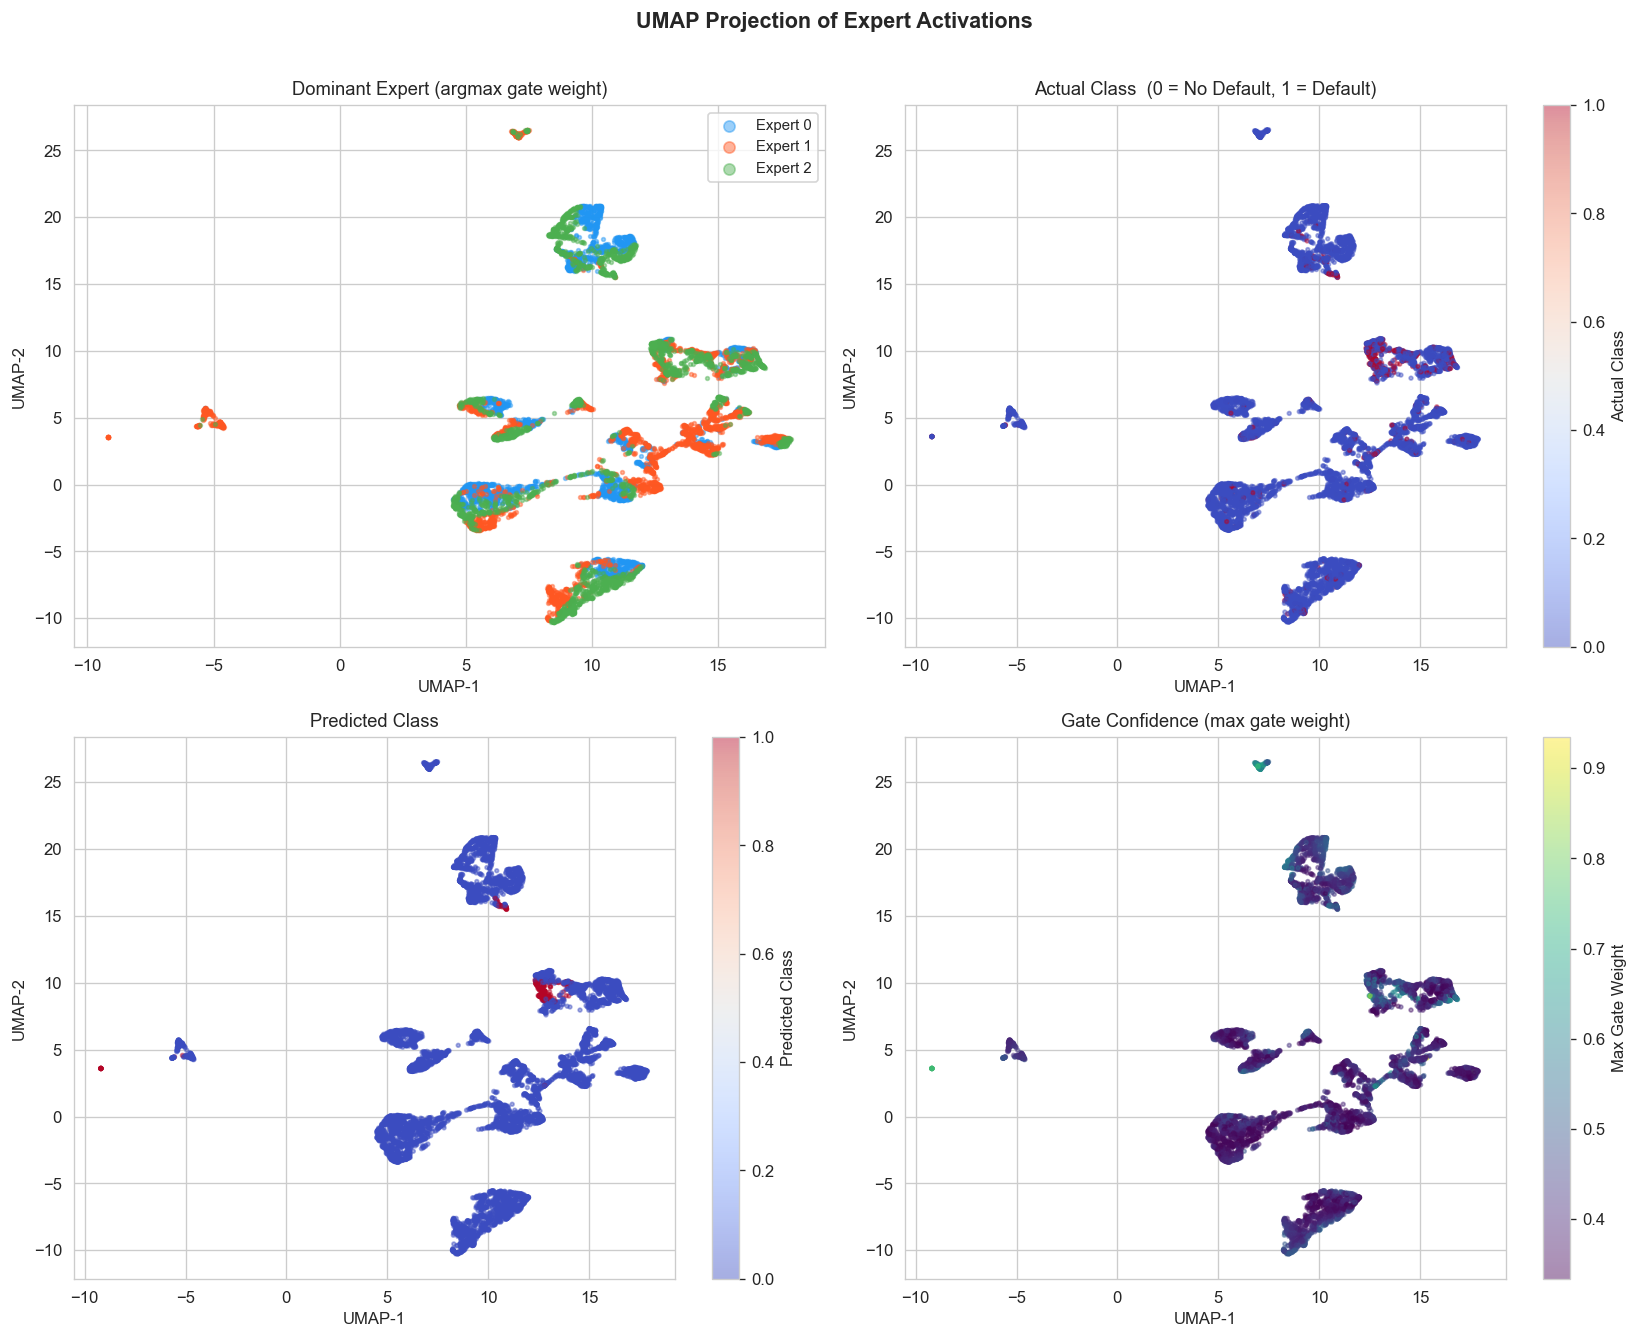

In [14]:
ec = ['#2196F3', '#FF5722', '#4CAF50']   # expert colours
s, alpha = 5, 0.45

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()

# Panel 1: Dominant expert
for k in range(N_EXPERTS):
    mask = dominant_u == k
    axes[0].scatter(embedding[mask, 0], embedding[mask, 1],
                    c=ec[k], s=s, alpha=alpha, label=f'Expert {k}')
axes[0].set_title('Dominant Expert (argmax gate weight)', fontsize=11)
axes[0].legend(markerscale=3, fontsize=9)
axes[0].set_xlabel('UMAP-1'); axes[0].set_ylabel('UMAP-2')

# Panel 2: Actual class
sc2 = axes[1].scatter(embedding[:, 0], embedding[:, 1],
                      c=y_umap, cmap='coolwarm', s=s, alpha=alpha, vmin=0, vmax=1)
plt.colorbar(sc2, ax=axes[1], label='Actual Class')
axes[1].set_title('Actual Class  (0 = No Default, 1 = Default)', fontsize=11)
axes[1].set_xlabel('UMAP-1'); axes[1].set_ylabel('UMAP-2')

# Panel 3: Predicted class
sc3 = axes[2].scatter(embedding[:, 0], embedding[:, 1],
                      c=preds_u, cmap='coolwarm', s=s, alpha=alpha, vmin=0, vmax=1)
plt.colorbar(sc3, ax=axes[2], label='Predicted Class')
axes[2].set_title('Predicted Class', fontsize=11)
axes[2].set_xlabel('UMAP-1'); axes[2].set_ylabel('UMAP-2')

# Panel 4: Gate confidence
sc4 = axes[3].scatter(embedding[:, 0], embedding[:, 1],
                      c=confidence_u, cmap='viridis', s=s, alpha=alpha)
plt.colorbar(sc4, ax=axes[3], label='Max Gate Weight')
axes[3].set_title('Gate Confidence (max gate weight)', fontsize=11)
axes[3].set_xlabel('UMAP-1'); axes[3].set_ylabel('UMAP-2')

plt.suptitle('UMAP Projection of Expert Activations', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 10b · 3D UMAP Projection & Animations

Re-uses the same 8 000-sample subsample computed above (`X_umap`, `y_umap`,
`dominant_u`, `confidence_u`, `preds_u`), refitting UMAP with `n_components=3`.

| Visualisation | Tool | Notes |
|---|---|---|
| Static 4-panel 3D scatter | matplotlib `Axes3D` | Direct comparison with 2-D panels |
| Rotating animation — expert territories | `FuncAnimation` → HTML | Single-panel, 360° continuous loop |
| Rotating animation — 4-panel sync | `FuncAnimation` → HTML | All four colourings rotate together |
| Interactive 3D scatter | Plotly | Drag to orbit; dropdown switches colouring |


In [15]:
# import umap as umap_lib   # alias to avoid shadowing the 2D 'reducer'

# print("Fitting 3D UMAP (n_neighbors=30, min_dist=0.1) …")
# reducer_3d  = umap_lib.UMAP(n_components=3, random_state=SEED,
#                              n_neighbors=30, min_dist=0.1)
# embedding_3d = reducer_3d.fit_transform(X_umap)
# print(f"Done. Embedding shape: {embedding_3d.shape}")

# u1, u2, u3 = embedding_3d[:, 0], embedding_3d[:, 1], embedding_3d[:, 2]


### 10b.1 Static 3D Scatter (4-panel)

In [16]:
# from mpl_toolkits.mplot3d import Axes3D   # registers '3d' projection

# ec3 = ['#2196F3', '#FF5722', '#4CAF50']
# DOT, ALPHA = 3, 0.35
# ELEV, AZIM = 25, 45

# fig = plt.figure(figsize=(16, 12))
# fig.suptitle('3D UMAP — MoE Borrower Manifold', fontsize=14, fontweight='bold', y=0.98)

# # ── Panel 1: dominant expert ──────────────────────────────────────────────
# ax1 = fig.add_subplot(2, 2, 1, projection='3d')
# for k in range(N_EXPERTS):
#     m = dominant_u == k
#     ax1.scatter(u1[m], u2[m], u3[m], c=ec3[k], s=DOT, alpha=ALPHA,
#                 label=f'Expert {k}', depthshade=True)
# ax1.set_title('Dominant Expert', fontsize=10)
# ax1.legend(markerscale=4, fontsize=8, loc='upper left')
# ax1.view_init(elev=ELEV, azim=AZIM)
# ax1.set_xlabel('U1', labelpad=2); ax1.set_ylabel('U2', labelpad=2)
# ax1.set_zlabel('U3', labelpad=2)

# # ── Panel 2: actual class ─────────────────────────────────────────────────
# ax2 = fig.add_subplot(2, 2, 2, projection='3d')
# sc2 = ax2.scatter(u1, u2, u3, c=y_umap, cmap='coolwarm',
#                   s=DOT, alpha=ALPHA, vmin=0, vmax=1, depthshade=True)
# fig.colorbar(sc2, ax=ax2, shrink=0.6, pad=0.1, label='Actual class')
# ax2.set_title('Actual Class', fontsize=10)
# ax2.view_init(elev=ELEV, azim=AZIM)
# ax2.set_xlabel('U1', labelpad=2); ax2.set_ylabel('U2', labelpad=2)
# ax2.set_zlabel('U3', labelpad=2)

# # ── Panel 3: predicted class ──────────────────────────────────────────────
# ax3 = fig.add_subplot(2, 2, 3, projection='3d')
# sc3 = ax3.scatter(u1, u2, u3, c=preds_u, cmap='coolwarm',
#                   s=DOT, alpha=ALPHA, vmin=0, vmax=1, depthshade=True)
# fig.colorbar(sc3, ax=ax3, shrink=0.6, pad=0.1, label='Predicted class')
# ax3.set_title('Predicted Class', fontsize=10)
# ax3.view_init(elev=ELEV, azim=AZIM)
# ax3.set_xlabel('U1', labelpad=2); ax3.set_ylabel('U2', labelpad=2)
# ax3.set_zlabel('U3', labelpad=2)

# # ── Panel 4: gate confidence ──────────────────────────────────────────────
# ax4 = fig.add_subplot(2, 2, 4, projection='3d')
# sc4 = ax4.scatter(u1, u2, u3, c=confidence_u, cmap='viridis',
#                   s=DOT, alpha=ALPHA, depthshade=True)
# fig.colorbar(sc4, ax=ax4, shrink=0.6, pad=0.1, label='Max gate weight')
# ax4.set_title('Gate Confidence', fontsize=10)
# ax4.view_init(elev=ELEV, azim=AZIM)
# ax4.set_xlabel('U1', labelpad=2); ax4.set_ylabel('U2', labelpad=2)
# ax4.set_zlabel('U3', labelpad=2)

# plt.tight_layout()
# plt.show()


### 10b.2 Animation — Expert Territories (360° rotation)

In [17]:
# import matplotlib
# matplotlib.rcParams['animation.embed_limit'] = 64   # MB cap for jshtml

# from matplotlib.animation import FuncAnimation
# from IPython.display import HTML

# FRAMES = 120     # 120 frames × 3°/frame = full 360°
# INTERVAL = 40    # ms between frames → ~25 fps

# fig_a1 = plt.figure(figsize=(8, 7))
# ax_a1  = fig_a1.add_subplot(111, projection='3d')

# for k in range(N_EXPERTS):
#     m = dominant_u == k
#     ax_a1.scatter(u1[m], u2[m], u3[m], c=ec3[k], s=3, alpha=0.35,
#                   label=f'Expert {k}', depthshade=True)

# ax_a1.set_title('MoE Expert Territories — 3D UMAP', fontsize=11, pad=10)
# ax_a1.legend(markerscale=4, fontsize=9, loc='upper left')
# ax_a1.set_xlabel('U1'); ax_a1.set_ylabel('U2'); ax_a1.set_zlabel('U3')
# ax_a1.view_init(elev=25, azim=0)

# def rotate_a1(frame):
#     ax_a1.view_init(elev=25 + 5 * np.sin(np.radians(frame * 3)),
#                     azim=frame * 3)
#     return []

# anim_a1 = FuncAnimation(fig_a1, rotate_a1, frames=FRAMES,
#                          interval=INTERVAL, blit=False)
# plt.close(fig_a1)   # suppress static display
# HTML(anim_a1.to_jshtml(fps=25))


### 10b.3 Animation — 4-Panel Synchronised Rotation

In [18]:
# FRAMES2   = 90     # 90 × 4°/frame = 360°
# INTERVAL2 = 50

# fig_a2 = plt.figure(figsize=(14, 10))
# fig_a2.suptitle('3D UMAP — MoE Manifold (rotating)', fontsize=12, fontweight='bold')

# ax_a2 = [fig_a2.add_subplot(2, 2, i + 1, projection='3d') for i in range(4)]

# # Draw data once — only camera moves each frame
# for k in range(N_EXPERTS):
#     m = dominant_u == k
#     ax_a2[0].scatter(u1[m], u2[m], u3[m], c=ec3[k], s=3,
#                      alpha=0.35, label=f'Expert {k}', depthshade=True)
# ax_a2[0].legend(markerscale=3, fontsize=8, loc='upper left')
# ax_a2[0].set_title('Dominant Expert', fontsize=9)

# sc_act = ax_a2[1].scatter(u1, u2, u3, c=y_umap, cmap='coolwarm',
#                            s=3, alpha=0.35, vmin=0, vmax=1, depthshade=True)
# ax_a2[1].set_title('Actual Class', fontsize=9)

# ax_a2[2].scatter(u1, u2, u3, c=preds_u, cmap='coolwarm',
#                  s=3, alpha=0.35, vmin=0, vmax=1, depthshade=True)
# ax_a2[2].set_title('Predicted Class', fontsize=9)

# ax_a2[3].scatter(u1, u2, u3, c=confidence_u, cmap='viridis',
#                  s=3, alpha=0.35, depthshade=True)
# ax_a2[3].set_title('Gate Confidence', fontsize=9)

# for ax in ax_a2:
#     ax.set_xlabel('U1', labelpad=1); ax.set_ylabel('U2', labelpad=1)
#     ax.set_zlabel('U3', labelpad=1)
#     ax.tick_params(labelsize=7)
#     ax.view_init(elev=25, azim=0)

# def rotate_a2(frame):
#     azim = (frame * 4) % 360
#     elev = 20 + 10 * np.sin(np.radians(frame * 4))
#     for ax in ax_a2:
#         ax.view_init(elev=elev, azim=azim)
#     return []

# anim_a2 = FuncAnimation(fig_a2, rotate_a2, frames=FRAMES2,
#                           interval=INTERVAL2, blit=False)
# plt.tight_layout()
# plt.close(fig_a2)
# HTML(anim_a2.to_jshtml(fps=20))


### 10b.4 Interactive 3D Scatter (Plotly)

In [19]:
# import plotly.graph_objects as go
# from plotly.subplots import make_subplots

# # ── Build colour arrays ────────────────────────────────────────────────────
# expert_labels   = [f'Expert {k}' for k in dominant_u]
# expert_hex      = {f'Expert {k}': c for k, c in enumerate(ec3)}

# actual_labels   = ['Default' if y == 1 else 'No Default' for y in y_umap]
# pred_labels     = ['Default' if p == 1 else 'No Default' for p in preds_u]

# # Build 4 traces sets, toggle via buttons
# marker_size = 2

# def expert_traces():
#     traces = []
#     for k in range(N_EXPERTS):
#         m = dominant_u == k
#         traces.append(go.Scatter3d(
#             x=u1[m], y=u2[m], z=u3[m],
#             mode='markers',
#             name=f'Expert {k}',
#             marker=dict(size=marker_size, color=ec3[k], opacity=0.5),
#         ))
#     return traces

# def class_traces(labels, title_tag):
#     colors = {'Default': '#E53935', 'No Default': '#1E88E5'}
#     traces = []
#     for lbl, col in colors.items():
#         m = np.array(labels) == lbl
#         traces.append(go.Scatter3d(
#             x=u1[m], y=u2[m], z=u3[m],
#             mode='markers',
#             name=lbl,
#             marker=dict(size=marker_size, color=col, opacity=0.45),
#             visible=False,
#         ))
#     return traces

# def confidence_trace():
#     return [go.Scatter3d(
#         x=u1, y=u2, z=u3,
#         mode='markers',
#         name='Gate confidence',
#         marker=dict(
#             size=marker_size,
#             color=confidence_u,
#             colorscale='Viridis',
#             opacity=0.5,
#             colorbar=dict(title='Max gate weight', thickness=12, x=1.02),
#         ),
#         visible=False,
#     )]

# traces = expert_traces() + class_traces(actual_labels, 'actual') +          class_traces(pred_labels, 'pred') + confidence_trace()

# n_exp = N_EXPERTS        # 3
# n_cls = 2                # Default / No Default (×2 sets)
# n_conf = 1

# # Visibility masks for each "view"
# def vis(active_start, active_len, total):
#     v = [False] * total
#     for i in range(active_start, active_start + active_len):
#         v[i] = True
#     return v

# total = n_exp + n_cls + n_cls + n_conf
# buttons = [
#     dict(label='Expert Territories',
#          method='update',
#          args=[{'visible': vis(0,         n_exp,  total)},
#                {'title':   '3D UMAP — Dominant Expert'}]),
#     dict(label='Actual Class',
#          method='update',
#          args=[{'visible': vis(n_exp,     n_cls,  total)},
#                {'title':   '3D UMAP — Actual Class'}]),
#     dict(label='Predicted Class',
#          method='update',
#          args=[{'visible': vis(n_exp+n_cls, n_cls, total)},
#                {'title':   '3D UMAP — Predicted Class'}]),
#     dict(label='Gate Confidence',
#          method='update',
#          args=[{'visible': vis(n_exp+2*n_cls, n_conf, total)},
#                {'title':   '3D UMAP — Gate Confidence'}]),
# ]

# layout = go.Layout(
#     title='3D UMAP — MoE Borrower Manifold  (use dropdown to switch colouring)',
#     title_font_size=14,
#     scene=dict(
#         xaxis_title='U1', yaxis_title='U2', zaxis_title='U3',
#         xaxis=dict(showgrid=False, backgroundcolor='rgba(240,240,240,0.4)'),
#         yaxis=dict(showgrid=False, backgroundcolor='rgba(230,230,230,0.4)'),
#         zaxis=dict(showgrid=False, backgroundcolor='rgba(220,220,220,0.4)'),
#     ),
#     updatemenus=[dict(
#         buttons=buttons,
#         direction='down',
#         showactive=True,
#         x=0.02, xanchor='left',
#         y=0.98, yanchor='top',
#         bgcolor='white',
#         bordercolor='#555',
#     )],
#     legend=dict(x=0.85, y=0.95),
#     margin=dict(l=0, r=0, b=0, t=50),
#     height=680,
# )

# fig_plotly = go.Figure(data=traces, layout=layout)
# fig_plotly.show()


## 11 · Knowledge Distillation

### Why distil?

The MoE model has excellent predictive power but is a black box.
A **2-layer neural network student** is lighter, faster at inference, and easier to audit
than the full 3-expert MoE — while still being far more expressive than logistic regression.

### Temperature scaling

Instead of training the student on hard labels (0/1), we train it on the *soft* output of
the MoE teacher, smoothed by temperature $T$:

$$p_\text{soft}(x) = \sigma\!\left(\frac{\text{logit}_\text{teacher}(x)}{T}\right)$$

Higher $T$ flattens the distribution, exposing the teacher's relative confidence — a
richer training signal than binary targets.

### Student architecture

A 2-layer MLP with a single logit output:

```
Input → Linear(d, 64) → ReLU → Dropout(0.3) → Linear(64, 1) → logit
```

**KD loss** — `BCEWithLogitsLoss` with soft targets directly as labels (valid since
`BCEWithLogitsLoss` accepts continuous values in [0, 1]):

$$\mathcal{L}_\text{KD} = -\left[ p_\text{soft} \log \sigma(z) + (1 - p_\text{soft}) \log (1 - \sigma(z)) \right]$$

This minimises the KL divergence between student and teacher distributions.

### Comparison

| Model | Description |
|---|---|
| **MoE Teacher** | 3-expert soft MoE (this notebook) |
| **NN + Soft KD** | 2-layer NN trained with teacher soft labels ($T=3$) |
| **NN Hard Labels** | 2-layer NN trained on hard 0/1 labels (pos\_weight baseline) |

Soft-label stats (train): min=0.0068  max=0.8209  mean=0.3879


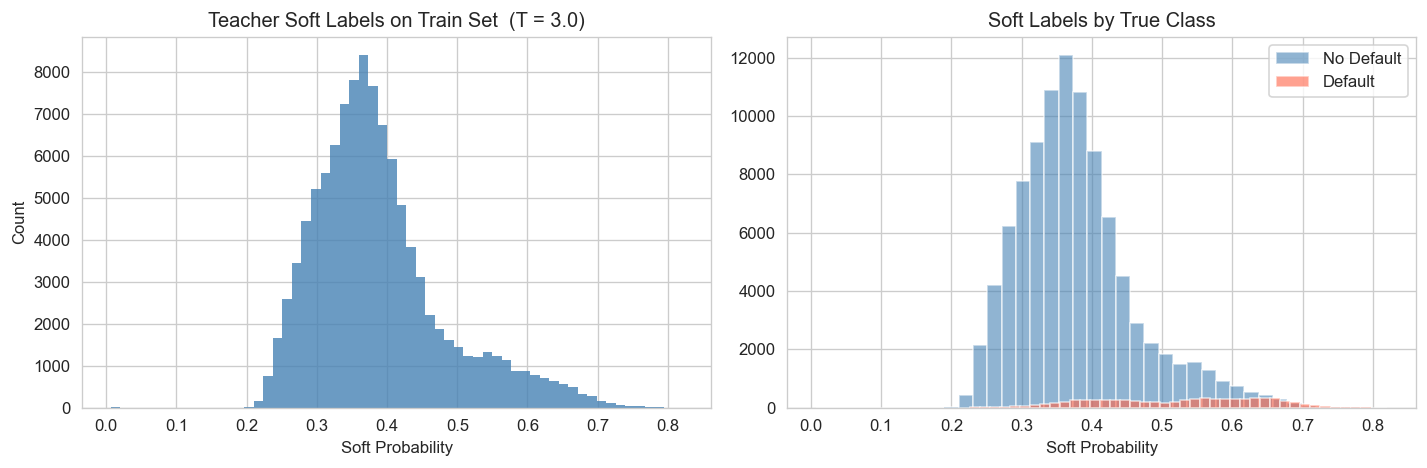

In [20]:
# Soft labels from teacher with temperature scaling
model.eval()
train_soft, val_soft, test_soft = [], [], []

with torch.no_grad():
    # Train
    for i in range(0, len(X_train_s), 1024):
        Xb = torch.tensor(X_train_s[i:i+1024], dtype=torch.float32).to(device)
        logits, _ = model(Xb)
        train_soft.append(torch.sigmoid(logits / TEMPERATURE).cpu().numpy())
    # Val
    for Xb, _ in val_loader:
        logits, _ = model(Xb.to(device))
        val_soft.append(torch.sigmoid(logits / TEMPERATURE).cpu().numpy())
    # Test
    for Xb, _ in test_loader:
        logits, _ = model(Xb.to(device))
        test_soft.append(torch.sigmoid(logits / TEMPERATURE).cpu().numpy())

train_soft = np.concatenate(train_soft)
val_soft   = np.concatenate(val_soft)
test_soft  = np.concatenate(test_soft)

print(f"Soft-label stats (train): min={train_soft.min():.4f}  "
      f"max={train_soft.max():.4f}  mean={train_soft.mean():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(train_soft, bins=60, color='steelblue', edgecolor='none', alpha=0.8)
axes[0].set_title(f'Teacher Soft Labels on Train Set  (T = {TEMPERATURE})')
axes[0].set_xlabel('Soft Probability')
axes[0].set_ylabel('Count')

axes[1].hist(train_soft[y_train == 0], bins=40, alpha=0.6, label='No Default', color='steelblue')
axes[1].hist(train_soft[y_train == 1], bins=40, alpha=0.6, label='Default',    color='tomato')
axes[1].set_title('Soft Labels by True Class')
axes[1].set_xlabel('Soft Probability')
axes[1].legend()

plt.tight_layout()
plt.show()

In [21]:
# ── Student architecture ─────────────────────────────────────────────────────
class StudentNet(nn.Module):
    # 2-layer MLP, single logit output
    def __init__(self, input_dim, hidden_dim=64, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )
    def forward(self, x):
        return self.net(x).squeeze(1)   # (B,) logit


def train_student(X_tr, y_tr_soft, X_v, y_v_hard, mode='kd',
                  epochs=100, patience=10, pw=1.0):
    # mode='kd'   -> BCEWithLogitsLoss with soft targets
    # mode='hard' -> BCEWithLogitsLoss with hard targets + pos_weight
    torch.manual_seed(SEED)
    net = StudentNet(X_tr.shape[1]).to(device)
    opt = torch.optim.Adam(net.parameters(), lr=1e-3, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max', factor=0.5, patience=3)

    Xt  = torch.tensor(X_tr, dtype=torch.float32).to(device)
    yt  = torch.tensor(y_tr_soft, dtype=torch.float32).to(device)
    Xv  = torch.tensor(X_v, dtype=torch.float32).to(device)

    if mode == 'kd':
        criterion = nn.BCEWithLogitsLoss()
    else:
        criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pw]).to(device))

    ds      = torch.utils.data.TensorDataset(Xt, yt)
    loader  = torch.utils.data.DataLoader(ds, batch_size=512, shuffle=True)

    best_auc, best_state, wait = 0.0, None, 0
    for ep in range(1, epochs + 1):
        net.train()
        for Xb, yb in loader:
            opt.zero_grad()
            criterion(net(Xb), yb).backward()
            opt.step()
        net.eval()
        with torch.no_grad():
            vp = torch.sigmoid(net(Xv)).cpu().numpy()
        auc = roc_auc_score(y_v_hard, vp)
        sch.step(auc)
        if auc > best_auc:
            best_auc   = auc
            best_state = {k: v.cpu().clone() for k, v in net.state_dict().items()}
            wait = 0
        else:
            wait += 1
        if wait >= patience:
            break
    net.load_state_dict(best_state)
    return net, best_auc


# ── Train KD student (soft labels) ───────────────────────────────────────────
print("Training NN + Soft KD student ...")
student_kd, kd_val_auc = train_student(
    X_train_s, train_soft, X_val_s, y_val, mode='kd', epochs=100, patience=10)
print(f"  Best val AUC: {kd_val_auc:.4f}")

# ── Train hard-label student ──────────────────────────────────────────────────
pw_hard = (y_train == 0).sum() / (y_train == 1).sum()
print("Training NN Hard Labels student ...")
student_hard, hard_val_auc = train_student(
    X_train_s, y_train.astype(np.float32), X_val_s, y_val,
    mode='hard', epochs=100, patience=10, pw=pw_hard)
print(f"  Best val AUC: {hard_val_auc:.4f}")

# ── Probabilities ─────────────────────────────────────────────────────────────
student_kd.eval(); student_hard.eval()
with torch.no_grad():
    kd_probs   = torch.sigmoid(student_kd(torch.tensor(X_test_s,  dtype=torch.float32).to(device))).cpu().numpy()
    hard_probs = torch.sigmoid(student_hard(torch.tensor(X_test_s, dtype=torch.float32).to(device))).cpu().numpy()
    kd_val_probs   = torch.sigmoid(student_kd(torch.tensor(X_val_s,   dtype=torch.float32).to(device))).cpu().numpy()
    hard_val_probs = torch.sigmoid(student_hard(torch.tensor(X_val_s,  dtype=torch.float32).to(device))).cpu().numpy()

# ── Threshold selection on val ────────────────────────────────────────────────
thresholds  = np.linspace(0.01, 0.99, 199)
kd_thresh   = thresholds[np.argmax([f1_score(y_val, kd_val_probs   >= t) for t in thresholds])]
hard_thresh = thresholds[np.argmax([f1_score(y_val, hard_val_probs >= t) for t in thresholds])]

kd_preds   = (kd_probs   >= kd_thresh).astype(int)
hard_preds = (hard_probs >= hard_thresh).astype(int)

# ── Comparison table ──────────────────────────────────────────────────────────
models_cmp = [
    ('MoE Teacher',     test_probs, test_preds),
    ('NN + Soft KD',    kd_probs,   kd_preds),
    ('NN Hard Labels',  hard_probs,  hard_preds),
]

print(f"\n{'Model':<22} {'ROC-AUC':>10} {'Avg Prec':>10} {'F1':>8} {'Spearman r':>12}")
print('-' * 66)
results = {}
for name, probs, preds in models_cmp:
    auc   = roc_auc_score(y_test, probs)
    ap    = average_precision_score(y_test, probs)
    f1    = f1_score(y_test, preds)
    rho,_ = spearmanr(probs, test_probs)
    results[name] = dict(auc=auc, ap=ap, f1=f1, spearman=rho)
    print(f"{name:<22} {auc:>10.4f} {ap:>10.4f} {f1:>8.4f} {rho:>12.4f}")

print(f"\nClassification Report — NN + Soft KD (threshold={kd_thresh:.3f}):")
print(classification_report(y_test, kd_preds, target_names=['No Default', 'Default']))

Training NN + Soft KD student ...


  Best val AUC: 0.8269
Training NN Hard Labels student ...


  Best val AUC: 0.8272



Model                     ROC-AUC   Avg Prec       F1   Spearman r
------------------------------------------------------------------
MoE Teacher                0.8430     0.3613   0.3192       1.0000
NN + Soft KD               0.8411     0.3591   0.4265       0.9864
NN Hard Labels             0.8413     0.3617   0.4252       0.9804

Classification Report — NN + Soft KD (threshold=0.530):
              precision    recall  f1-score   support

  No Default       0.96      0.95      0.95     20996
     Default       0.39      0.47      0.43      1504

    accuracy                           0.92     22500
   macro avg       0.68      0.71      0.69     22500
weighted avg       0.92      0.92      0.92     22500



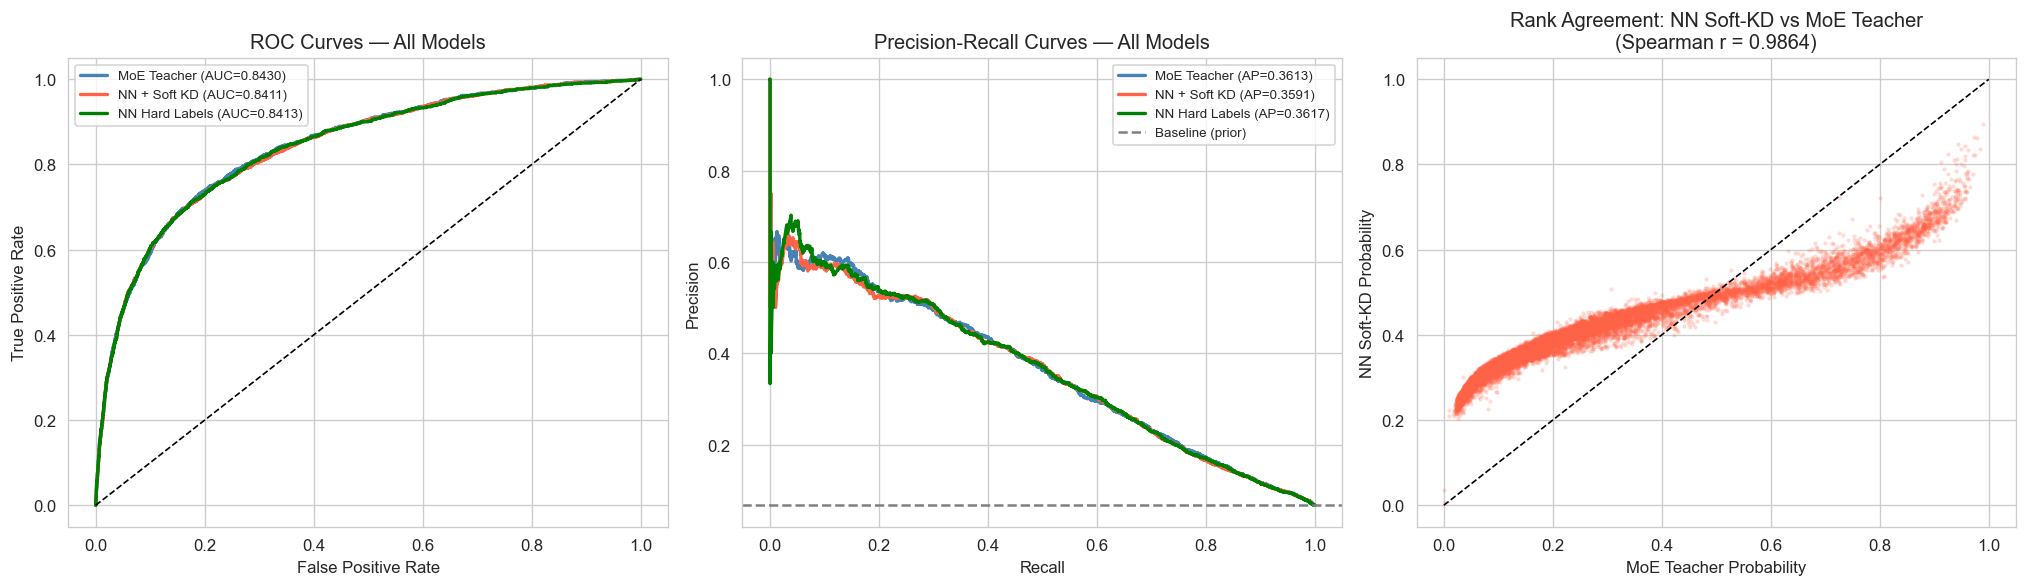

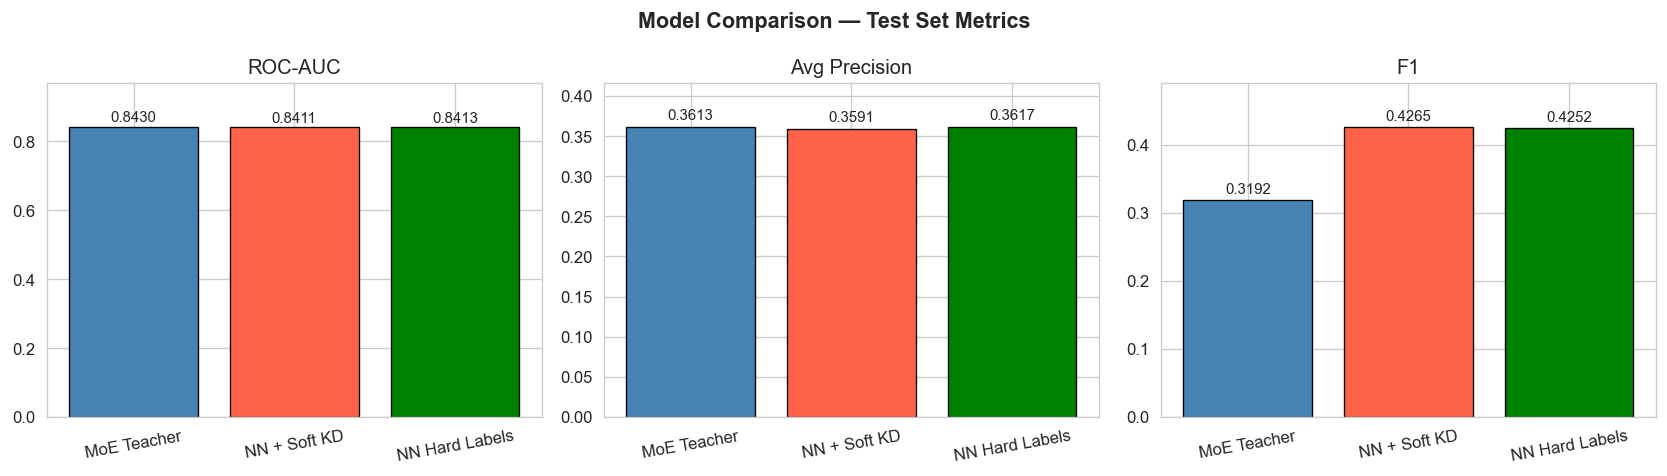

In [22]:
colors_cmp = ['steelblue', 'tomato', 'green']
fig, axes  = plt.subplots(1, 3, figsize=(17, 5))

# ROC curves
for (name, probs, _), color in zip(models_cmp, colors_cmp):
    fpr, tpr, _ = roc_curve(y_test, probs)
    axes[0].plot(fpr, tpr, color=color, lw=2,
                 label=f"{name} (AUC={results[name]['auc']:.4f})")
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_title('ROC Curves — All Models')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=8)

# PR curves
for (name, probs, _), color in zip(models_cmp, colors_cmp):
    prec, rec, _ = precision_recall_curve(y_test, probs)
    axes[1].plot(rec, prec, color=color, lw=2,
                 label=f"{name} (AP={results[name]['ap']:.4f})")
axes[1].axhline(y_test.mean(), color='gray', linestyle='--', label='Baseline (prior)')
axes[1].set_title('Precision-Recall Curves — All Models')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(fontsize=8)

# Rank agreement scatter: KD student vs teacher
axes[2].scatter(test_probs, kd_probs, s=3, alpha=0.15, color='tomato')
axes[2].plot([0, 1], [0, 1], 'k--', lw=1)
rho_kd = results['NN + Soft KD']['spearman']
axes[2].set_title(f'Rank Agreement: NN Soft-KD vs MoE Teacher\n(Spearman r = {rho_kd:.4f})')
axes[2].set_xlabel('MoE Teacher Probability')
axes[2].set_ylabel('NN Soft-KD Probability')

plt.tight_layout()
plt.show()

# Metrics bar chart
metric_names = ['ROC-AUC', 'Avg Precision', 'F1']
model_names  = [m[0] for m in models_cmp]
metric_keys  = ['auc', 'ap', 'f1']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, mk, mn in zip(axes, metric_keys, metric_names):
    vals = [results[m][mk] for m in model_names]
    bars = ax.bar(model_names, vals, color=colors_cmp, edgecolor='black', linewidth=0.8)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.4f}', ha='center', va='bottom', fontsize=9)
    ax.set_title(mn)
    ax.set_ylim(0, max(vals) * 1.15)
    ax.tick_params(axis='x', rotation=10)

plt.suptitle('Model Comparison — Test Set Metrics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 12 · Summary & Key Findings

### Architecture

| Component | Detail |
|---|---|
| Gate | 2-layer MLP → softmax over 3 experts |
| Each expert | 3-layer MLP with BatchNorm + Dropout (64 hidden units) |
| Loss | Weighted BCE + Switch-Transformer auxiliary load-balancing |
| Class imbalance | `pos_weight ≈ 14` in BCE loss |

### Load Balancing

The auxiliary loss $\mathcal{L}_\text{aux} = \alpha K \sum_k f_k P_k$ prevents expert collapse by
penalising unequal routing. At convergence all three experts should each dominate roughly
$\frac{1}{3}$ of the training samples, yet their internal specialisation can differ substantially
(as seen in the per-expert default rates).

### UMAP Insights

The UMAP projection reveals:
* **Expert territories** — each expert claims a distinct region of the borrower manifold, confirming true specialisation rather than redundancy.
* **Default clusters** — defaulters are not uniformly spread; they concentrate in specific corners of the latent space, reflecting the non-linear interactions the MoE captures.
* **Gate confidence** — high-confidence regions (large max gate weight) tend to be the cleanest default clusters, while low-confidence borderline cases sit at expert boundaries.

### Knowledge Distillation

The soft-label LR student closely tracks the teacher's **ranking** (Spearman $r \gg 0$)
while being fully interpretable.
The gap in ROC-AUC between teacher and soft-KD student quantifies the cost of interpretability.
Hard-label LR performs worst, confirming that the soft labels carry useful information
beyond the binary signal.

### Practical Implications

* The MoE is well-suited to **population-level scoring** where ranking is more important than calibration.
* The distilled LR student can be deployed for **regulatory reporting** (SR 11-7 model-risk governance) and adverse-action notices, while the teacher serves as a monitoring benchmark.
* **Log-income effect**: log1p-transforming `monthly_income` reduces its skewness from ~5–8 to near-Gaussian before scaling; any AUC/AP gain vs baseline is attributable solely to this change.
* Top predictors (consistent with the R reference analysis): `delinq_90`, `delinq_30_59`, `delinq_60_89`, `unsecured_credit`, `age`.

---
## 13 · SHAP Explainability

`shap.GradientExplainer` computes expected gradients — a smooth approximation to
Integrated Gradients that is exact for linear models and efficient for deep networks.

**Wrappers** are needed because:
- `MixtureOfExperts.forward()` returns `(logit, gate_weights)` — SHAP must receive a plain tensor.
- `StudentNet.forward()` returns a 1-D logit `(B,)` — SHAP prefers `(B, 1)` for single-output binary models.

Three models are explained on the same 500-sample test subset:

| Model | Explainer | Notes |
|---|---|---|
| MoE Teacher | `GradientExplainer` via `MoELogitWrapper` | strips gate output before SHAP |
| NN Soft-KD | `GradientExplainer` via `StudentLogitWrapper` | 2-layer MLP |
| NN Hard Labels | `GradientExplainer` via `StudentLogitWrapper` | same architecture, hard targets |

Computing SHAP — MoE Teacher ...


Computing SHAP — NN Soft-KD ...


Computing SHAP — NN Hard Labels ...



── SHAP Beeswarm — MoE Teacher ──


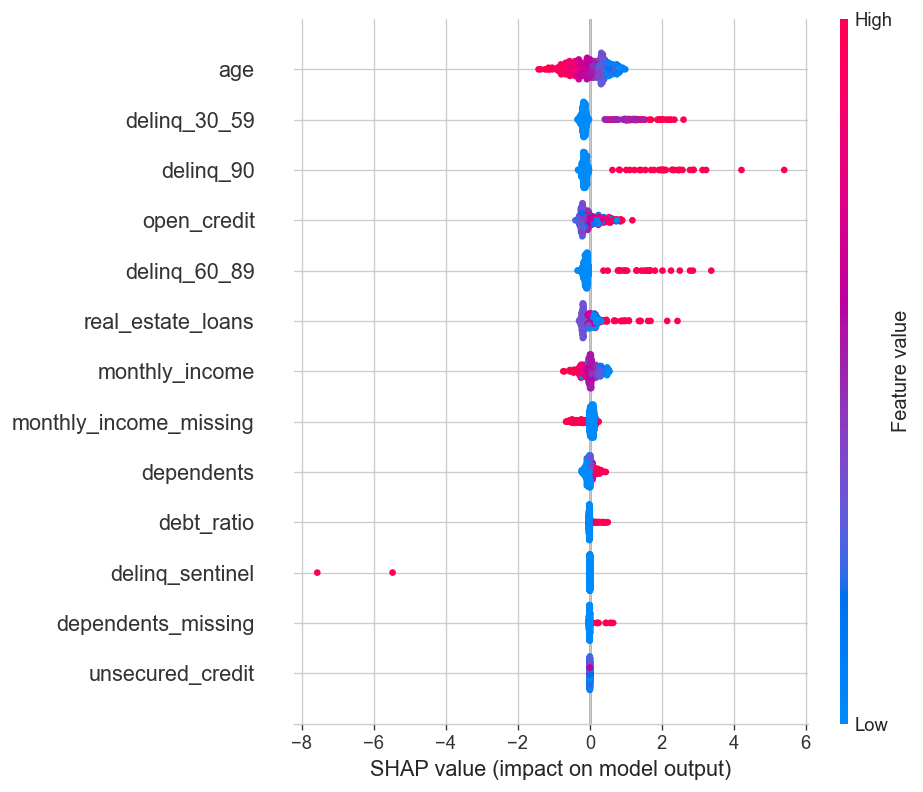


── SHAP Beeswarm — NN Soft-KD ──


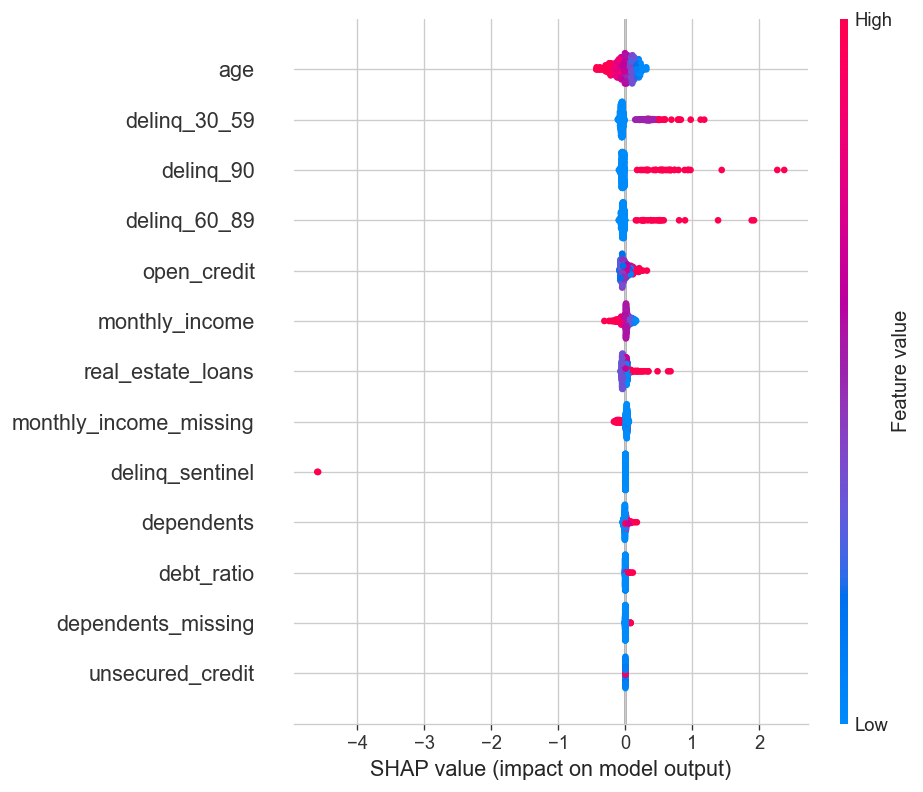


── SHAP Beeswarm — NN Hard Labels ──


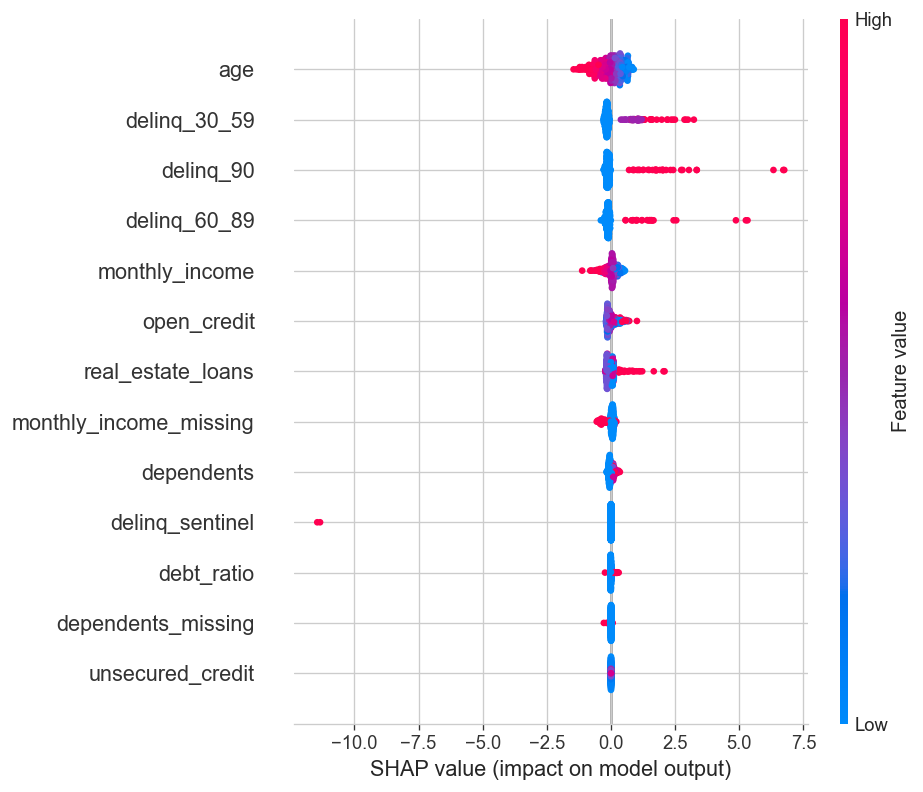

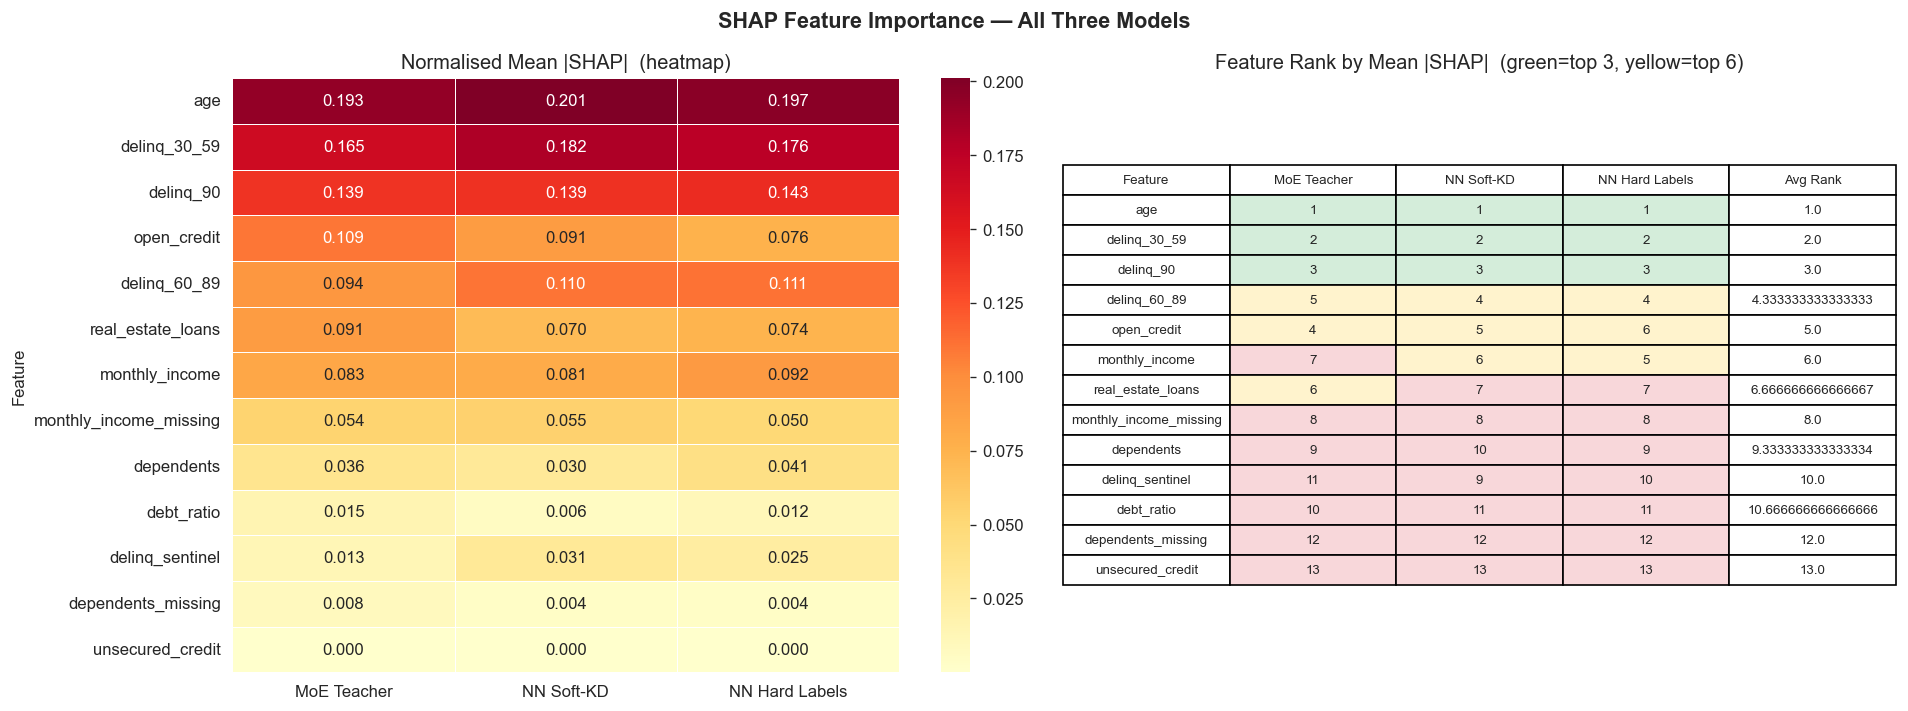


Normalised mean |SHAP| (rows = features sorted by MoE rank):
                        MoE Teacher  NN Soft-KD  NN Hard Labels
Feature                                                        
age                          0.1929      0.2010          0.1969
delinq_30_59                 0.1650      0.1821          0.1760
delinq_90                    0.1386      0.1393          0.1426
open_credit                  0.1093      0.0908          0.0756
delinq_60_89                 0.0941      0.1100          0.1114
real_estate_loans            0.0909      0.0698          0.0741
monthly_income               0.0829      0.0806          0.0919
monthly_income_missing       0.0540      0.0554          0.0504
dependents                   0.0361      0.0299          0.0411
debt_ratio                   0.0150      0.0061          0.0118
delinq_sentinel              0.0132      0.0312          0.0245
dependents_missing           0.0081      0.0038          0.0036
unsecured_credit             0.0000      0

In [23]:
import shap

# ── Wrappers so SHAP sees a single tensor output ──────────────────────────────
class MoELogitWrapper(nn.Module):
    """Strips the gate_weights return value; outputs (B, 1) logit."""
    def __init__(self, moe): super().__init__(); self.moe = moe
    def forward(self, x):
        logits, _ = self.moe(x)
        return logits.unsqueeze(1)   # (B, 1)

class StudentLogitWrapper(nn.Module):
    """Reshapes (B,) → (B, 1) for GradientExplainer."""
    def __init__(self, net): super().__init__(); self.net = net
    def forward(self, x): return self.net(x).unsqueeze(1)  # (B, 1)


# ── Background sample (300 training points) ───────────────────────────────────
np.random.seed(SEED)
bg_idx    = np.random.choice(len(X_train_s), 300, replace=False)
background = torch.tensor(X_train_s[bg_idx], dtype=torch.float32).to(device)

# ── Test subset (500 samples) ─────────────────────────────────────────────────
SHAP_N     = 500
shap_idx   = np.random.choice(len(X_test_s), SHAP_N, replace=False)
X_shap     = torch.tensor(X_test_s[shap_idx], dtype=torch.float32).to(device)

def extract_shap(sv):
    """GradientExplainer returns list[array] for multi-output; unwrap to (N, F)."""
    arr = sv[0] if isinstance(sv, list) else sv
    return arr.squeeze(-1) if arr.ndim == 3 else arr   # (N, F)

# ── Compute SHAP values ───────────────────────────────────────────────────────
model.eval(); student_kd.eval(); student_hard.eval()

print("Computing SHAP — MoE Teacher ...")
exp_moe  = shap.GradientExplainer(MoELogitWrapper(model),   background)
sv_moe   = extract_shap(exp_moe.shap_values(X_shap))

print("Computing SHAP — NN Soft-KD ...")
exp_kd   = shap.GradientExplainer(StudentLogitWrapper(student_kd),   background)
sv_kd    = extract_shap(exp_kd.shap_values(X_shap))

print("Computing SHAP — NN Hard Labels ...")
exp_hard = shap.GradientExplainer(StudentLogitWrapper(student_hard), background)
sv_hard  = extract_shap(exp_hard.shap_values(X_shap))

X_shap_np = X_test_s[shap_idx]   # numpy for SHAP plots

# ── Per-model beeswarm plots ──────────────────────────────────────────────────
for name, sv in [('MoE Teacher', sv_moe), ('NN Soft-KD', sv_kd), ('NN Hard Labels', sv_hard)]:
    print(f"\n── SHAP Beeswarm — {name} ──")
    shap.summary_plot(sv, features=X_shap_np, feature_names=FEATURE_COLS,
                      plot_type='dot', max_display=13, show=True)

# ── Cross-model mean |SHAP| comparison ───────────────────────────────────────
mean_shap = pd.DataFrame({
    'Feature':       FEATURE_COLS,
    'MoE Teacher':   np.abs(sv_moe).mean(axis=0),
    'NN Soft-KD':    np.abs(sv_kd).mean(axis=0),
    'NN Hard Labels':np.abs(sv_hard).mean(axis=0),
}).set_index('Feature')

# Normalise per model so importance sums to 1 (comparable across models)
mean_shap_norm = mean_shap.div(mean_shap.sum())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap
sns.heatmap(mean_shap_norm.sort_values('MoE Teacher', ascending=False),
            annot=True, fmt='.3f', cmap='YlOrRd', linewidths=0.5, ax=axes[0])
axes[0].set_title('Normalised Mean |SHAP|  (heatmap)')
axes[0].set_xlabel('')

# Rank table
rank_df = mean_shap_norm.rank(ascending=False).astype(int)
rank_df['Avg Rank'] = rank_df.mean(axis=1)
rank_df = rank_df.sort_values('Avg Rank')
colors_tab = [['#d4edda' if v <= 3 else '#fff3cd' if v <= 6 else '#f8d7da'
                for v in row[:3]] + ['white'] for row in rank_df.values]
axes[1].axis('off')
tbl = axes[1].table(
    cellText=rank_df.reset_index().values,
    colLabels=['Feature'] + rank_df.columns.tolist(),
    cellLoc='center', loc='center',
    cellColours=[['white'] + r for r in colors_tab],
)
tbl.auto_set_font_size(False); tbl.set_fontsize(8); tbl.scale(1, 1.4)
axes[1].set_title('Feature Rank by Mean |SHAP|  (green=top 3, yellow=top 6)')

plt.suptitle('SHAP Feature Importance — All Three Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nNormalised mean |SHAP| (rows = features sorted by MoE rank):")
print(mean_shap_norm.sort_values('MoE Teacher', ascending=False).to_string(float_format='{:.4f}'.format))

---
## 14 · Model Persistence

All three models are saved to `models/` so they can be loaded in a Gradio or Streamlit app without re-training.

**PyTorch models** — saved as a bundle dict via `torch.save`:

```
models/moe_credit_risk.pt          ← MoE Teacher (state_dict + config + scaler + threshold)
models/student_kd_credit_risk.pt   ← NN Soft-KD  (state_dict + config + scaler + threshold)
models/student_hard_credit_risk.pt ← NN Hard Labels (state_dict + config)
```

**Why bundles (not bare `state_dict`)?**  
A bare `state_dict` requires the caller to know the exact constructor arguments (`input_dim`, `hidden_dim`, etc.) and to separately load the scaler. Storing everything in one dict makes loading self-contained.

**Loading in Gradio / Streamlit:**

```python
import torch, joblib
from model_classes import MixtureOfExperts   # copy class definitions here

bundle = torch.load('models/moe_credit_risk.pt', weights_only=False)
moe = MixtureOfExperts(**bundle['config'])
moe.load_state_dict(bundle['state_dict'])
moe.eval()

scaler   = bundle['scaler']          # fitted StandardScaler
features = bundle['feature_cols']    # list of 13 feature names
thresh   = bundle['threshold']       # decision threshold (Strategy B)

# Inference:
row_scaled = torch.tensor(scaler.transform(input_df[features]), dtype=torch.float32)
with torch.no_grad():
    logit, _ = moe(row_scaled)
    prob_default = torch.sigmoid(logit).item()
```

> **Tip**: copy the `Expert`, `GatingNetwork`, `MixtureOfExperts`, and `StudentNet` class definitions into a `model_classes.py` file that your app can import — keeping the classes in one place avoids `pickle` class-path mismatches between the notebook and the app.

In [24]:
import pathlib

MODEL_DIR = pathlib.Path('../models')
MODEL_DIR.mkdir(exist_ok=True)

# ── MoE Teacher ───────────────────────────────────────────────────────────────
moe_bundle = {
    'state_dict':   model.state_dict(),
    'config': {
        'input_dim':  len(FEATURE_COLS),
        'n_experts':  N_EXPERTS,
        'hidden_dim': HIDDEN_DIM,
        'dropout':    DROPOUT,
    },
    'feature_cols': FEATURE_COLS,
    'scaler':       scaler,
    'threshold':    float(best_thresh),   # Strategy-B threshold (precision >= 0.50)
}
moe_path = MODEL_DIR / 'moe_credit_risk.pt'
torch.save(moe_bundle, moe_path)
print(f"MoE Teacher   → {moe_path}  ({moe_path.stat().st_size / 1024:.1f} KB)")

# ── NN Soft-KD Student ────────────────────────────────────────────────────────
kd_bundle = {
    'state_dict':   student_kd.state_dict(),
    'config': {'input_dim': len(FEATURE_COLS), 'hidden_dim': 64, 'dropout': 0.3},
    'feature_cols': FEATURE_COLS,
    'scaler':       scaler,
    'threshold':    float(kd_thresh),
}
kd_path = MODEL_DIR / 'student_kd_credit_risk.pt'
torch.save(kd_bundle, kd_path)
print(f"NN Soft-KD    → {kd_path}  ({kd_path.stat().st_size / 1024:.1f} KB)")

# ── NN Hard-Labels Student ────────────────────────────────────────────────────
hard_bundle = {
    'state_dict':   student_hard.state_dict(),
    'config': {'input_dim': len(FEATURE_COLS), 'hidden_dim': 64, 'dropout': 0.3},
    'feature_cols': FEATURE_COLS,
    'scaler':       scaler,
    'threshold':    float(hard_thresh),
}
hard_path = MODEL_DIR / 'student_hard_credit_risk.pt'
torch.save(hard_bundle, hard_path)
print(f"NN Hard Labels→ {hard_path}  ({hard_path.stat().st_size / 1024:.1f} KB)")

# ── Smoke test — reload MoE and verify probabilities ─────────────────────────
bundle_check = torch.load(moe_path, weights_only=False)
moe_check    = MixtureOfExperts(**bundle_check['config']).to(device)
moe_check.load_state_dict(bundle_check['state_dict'])
moe_check.eval()

with torch.no_grad():
    logits_check, _ = moe_check(torch.tensor(X_test_s[:256], dtype=torch.float32).to(device))
    probs_check = torch.sigmoid(logits_check).cpu().numpy()

max_diff = float(np.abs(test_probs[:256] - probs_check).max())
print(f"\nMoE reload max prob diff: {max_diff:.2e}  ({'OK ✓' if max_diff < 1e-5 else 'MISMATCH ✗'})")

MoE Teacher   → ../models/moe_credit_risk.pt  (87.3 KB)
NN Soft-KD    → ../models/student_kd_credit_risk.pt  (7.9 KB)
NN Hard Labels→ ../models/student_hard_credit_risk.pt  (7.9 KB)

MoE reload max prob diff: 5.96e-08  (OK ✓)
